In [95]:
# Import necessary libraries
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import gc

In [100]:
# User Input Parameters (CHANGE)
date_str = "20260302"  # YYYYMMDD format
start_time = "000000"  # HHMMSS format
end_time = "235959"  # HHMMSS format

end_time_mask = end_time # for full-day plots

# Convert strings to datetime objects for filtering
date_obj = datetime.strptime(date_str, "%Y%m%d")
start_time_obj = datetime.strptime(date_str + start_time, "%Y%m%d%H%M%S")
end_time_obj = datetime.strptime(date_str + end_time, "%Y%m%d%H%M%S")

# Convert mask time if provided
if end_time_mask is not None:
    end_time_mask_obj = datetime.strptime(date_str + end_time_mask, "%Y%m%d%H%M%S")
else:
    end_time_mask_obj = None

# Define friendly name mapping (from multi_plot_add_acoustic.ipynb)
pv_mapping = [
    # --- Vacuum Pressure Sensors ---

    # --- Radiation and Detectors ---
    ("B2_VXD:Rad:Res:BPAtDCU3:A1:DoseRate", "B_DMD_DoseRate"),
    ("B2_VXD:Rad:QCS_FW_225:DoseRate", "B_DMD_FW_225L"),
    ("B2_VXD:Rad:QCS_FW_135:DoseRate", "B_DMD_FW_135L"),
    ("B2_CDC:CUR:LOGGER:L15_2:MAX", "B_CDC_Imax_uA"),
    ("B2_CDC:CUR_AVERAGE", "B_CDC_Iavg_uA"),
    ("B2_TOP:TYPE2_avg_scalerRate_PMT17-32", "B_PMThits_Hz"),
    ("B2_TOP:TYPE2_avg_scalerRate_PMT17-32_60", "B_PMThits_avg60s"),
    ("B2_nsm:get:TRGOSCILLO0:lff_ler", "B_ECL_BG_duration_ms"),
    ("B2_nsm:get:ECLTRG_FAM:rate_bw", "B_ECL_BW"),

    # --- Beam Parameters and Injection ---
    ("B2_nsm:get:ECL_LUM_MON:lum_acc_20", "A_LUMI_30"),
    ("CG_OPR:SpecificLuminosity", "A_LUMI_SP_30"),
    ("BMLDCCT:CURRENT", "A_LER_Current_mA"),
    ("BMLDCCT:RATE", "A_LER_Inj_Rate_mAps"),
    ("BMLDCCT:LIFE", "A_LER_Lifetime_min"),
    ("CGLOPT:IP:BETA_Y", "A_LER_BetaY_IP_m"),
    ("CGLOPT:IP:BETA_X", "A_LER_BetaX_IP_m"),
    ("BMLXRM:BEAM:SIGMAX", "A_LER_SigmaX_IP_um"),
    ("BMLXRM:BEAM:SIGMAY", "A_LER_SigmaY_IP_um"),
    ("CG_OPT:CAP:SIGMAY", "A_LER_CapSigmaY_um"),
    ("LIiBM:SP_61_8_1:ISNGL:KBP", "A_Q_LER_Linac_end_nC"),
    ("CGLINJ:EFFICIENCY", "A_LER_Tot_INJ_Effi"),
    ("LIiEV:BEAM_REP:READ:KBP", "A_LER_Rep_ep_Hz"),
    ("CGLINJ:KICKER:HEIGHT_R", "A_LER_Kicker_Height_mm"),
    ("CGLINJ:KICKER:JUMP_R", "A_LER_Kicker_Jump"),
    ("CGLINJ:SEPTUM:POS_R", "A_LER_Septum_Pos_mm"),
    ("CGLINJ:SEPTUM:ANG_R", "A_LER_Septum_Ang_mm"),
    ("LIiRF:MOPS:SET_PHASE:LER", "A_LER_INJ_Phase"),
    ("CGLINJ:INJECTION:YPOS", "A_LER_INJ_PosY_m"),
    ("CGLINJ:INJECTION:YANG", "A_LER_INJ_AngY_rad"),
    ("BMLD07:INJ:X", "A_LER_INJ_D7_BPMX_mm"),
    ("BMLD07:INJ:Y", "A_LER_INJ_D7_BPMY_mm"),
    ("BMLD07:INJ:Q", "A_LER_INJ_D7_Charge"),
    ("VALCLM:D06CV1TOP:RQ:SET_POS", "A_D6V1_TOP_Head_Pos_Set"),
    ("VALCLM:D06CV1TOP:ST:POS", "A_D6V1_TOP_Head_Pos_Meas"),
    ("VALCLM:D06CV1BTM:RQ:SET_POS", "A_D6V1_BTM_Head_Pos_Set"),
    ("VALCLM:D06CV1BTM:ST:POS", "A_D6V1_BTM_Head_Pos_Meas"),
    ("BML:MQTAFOP1:POS.PXP", "A_D6V1_Upstrm_BPM_PosX"),
    ("BML:MQTAFOP1:POS.PYP", "A_D6V1_Upstrm_BPM_PosY"),
    ("BML:MQT3FOP1:POS.PXP", "A_D6V1_Downstrm_BPM_PosX"),
    ("BML:MQT3FOP1:POS.PYP", "A_D6V1_Downstrm_BPM_PosY"),
    ("BM_BLM:BTCBT:ADC:MEAN", "A_INJ_Loss_Monitor"),

    # --- Acoustic Sensors ---
    ("RFLAE:D06:OSC1:CH1:MIN", "ACOU_Top_Min"),
    ("RFLAE:D06:OSC1:CH1:MAX", "ACOU_Top_Max"),
    ("RFLAE:D06:OSC1:CH1:VPP", "ACOU_Top_Vpp"),
    ("RFLAE:D06:OSC1:CH2:MIN", "ACOU_BmLoss_Min"),
    ("RFLAE:D06:OSC1:CH2:MAX", "ACOU_BmLoss_Max"),
    ("RFLAE:D06:OSC1:CH2:VPP", "ACOU_BmLoss_Vpp"),
    ("RFLAE:D06:OSC1:CH3:MIN", "ACOU_Btm_Min"),
    ("RFLAE:D06:OSC1:CH3:MAX", "ACOU_Btm_Max"),
    ("RFLAE:D06:OSC1:CH3:VPP", "ACOU_Btm_Vpp"),
    
    # --- Top Block (Positron/LER) ---
    ("BTpBPM:QMD11P_K_1:NC_1Hz", "A_Q_LERB1_BT_end_nC"),
    ("BTpBPM:QMD11P_K_1:NC_1Hz:C", "A_Q_LERB1_BT_end_nC"),
    ("BTpBPM:QMD11P_K_2:NC_1Hz", "A_Q_LERB2_BT_end_nC"),
    ("TM_EVR0:LER:INJ_EFF:BCM1", "A_Inj_Effi_LERB1_BT_end"),
    ("TM_EVR0:LER:INJ_EFF:BCM2", "A_Inj_Effi_LERB2_BT_end"),

    # --- Electron (e-) Monitoring ---
    ("BTeBPM:QMD8E_M_1:NC_1Hz", "A_Q_HERB1_BT_end_nC"),
    ("BTeBPM:QMD8E_M_2:NC_1Hz", "A_Q_HERB2_BT_end_nC"),
    ("TM_EVR0:HER:INJ_EFF:BCM1", "A_Inj_Effi_HERB1_BT_end"),
    ("TM_EVR0:HER:INJ_EFF:BCM2", "A_Inj_Effi_HERB2_BT_end"),
    ("CGHINJ:EFFICIENCY", "A_HER_Tot_INJ_Effi"),
    ("LIiEV:BEAM_REP:READ:KBE", "A_HER_Rep_ep_Hz"),

    # --- VXD Background ---
    ("B2_VXD:Rad:QCS_BW_180:DoseRate", "B_DMD_BW_180H"),
    ("B2_VXD:Rad:QCS_BW_270:DoseRate", "B_DMD_BW_270H"),

    # --- Loss Monitor Signals (HER-injection) ---
    ("CLAWS_INJ:D10:PS3000:A:IntegralTotal", "D09V3-HER"),
    ("CLAWS_INJ:D12:PS3000:A:IntegralTotal", "D12V4-HER"),
    ("B2_BEAST:CLAWS_INJ:EhutH:PS3000:A:IntegralTotal", "D01V1-HER"),
    ("CLAWS_INJ:D7:PS3000:D:IntegralTotal", "D06V1-LER"),
    ("CLAWS_INJ:D5:PS3000:B:IntegralTotal", "D05V1-LER"),
    ("CLAWS_INJ:D5:PS3000:A:IntegralTotal", "D03V4-LER"),
    ("B2_BEAST:CLAWS_INJ:EhutL:PS3000:A:IntegralTotal", "D02V1-LER"),

    # --- Other HER ---
    ("BMHDCCT:CURRENT", "A_HER_Current_mA"),
    ("BMHDCCT:RATE", "A_HER_Inj_Rate_mAps"),
    ("BMHDCCT:LIFE", "A_HER_Lifetime_min")
]

# Create mapping dictionary for fast lookup
pv_dict = {k: v for k, v in pv_mapping}

# Function to get friendly name or return original column name if not found
def get_friendly_name(col_name):
    return pv_dict.get(col_name, col_name)

print(f"Loaded {len(pv_mapping)} PV name mappings")

# Load machine data from Machine_Inj_BG_byDay folder
# Extract MMDD from date_str (e.g., "20260223" -> "0223")
mmdd = date_str[4:8]  # Get MMDD from YYYYMMDD
machine_base_path = "/Users/xylu/Desktop/Data/Machine_Data_LER_HER_Acoustic/"
machine_folder = os.path.join(machine_base_path, mmdd)

if not os.path.exists(machine_folder):
    print(f"⚠ Machine folder not found: {machine_folder}")
    machine_df = None
else:
    print(f"✓ Found Machine folder: {machine_folder}")
    
    # Find CSV files in Machine folder
    machine_csv_files = sorted(glob.glob(os.path.join(machine_folder, "*.csv")))
    
    if len(machine_csv_files) == 0:
        print(f"  ⚠ No CSV files found in Machine folder")
        machine_df = None
    else:
        print(f"  Found {len(machine_csv_files)} machine data file(s)")
        
        # Load and combine all machine data files
        machine_data_list = []
        
        for csv_file in machine_csv_files:
            try:
                df_temp = pd.read_csv(csv_file)
                # Convert timestamp column to datetime (handle both #date and Timestamp)
                if '#date' in df_temp.columns:
                    df_temp['#date'] = pd.to_datetime(df_temp['#date'], format='ISO8601')
                    df_temp.rename(columns={'#date': 'time_datetime'}, inplace=True)
                elif 'Timestamp' in df_temp.columns:
                    df_temp['Timestamp'] = pd.to_datetime(df_temp['Timestamp'], format='ISO8601')
                    df_temp.rename(columns={'Timestamp': 'time_datetime'}, inplace=True)
                machine_data_list.append(df_temp)
                print(f"  ✓ {os.path.basename(csv_file)}: {len(df_temp)} samples, {len(df_temp.columns)} columns")
            except Exception as e:
                print(f"  ✗ Error reading {os.path.basename(csv_file)}: {e}")
        
        if machine_data_list:
            # Combine all machine data
            machine_df = pd.concat(machine_data_list, ignore_index=True)
            machine_df = machine_df.sort_values('time_datetime').reset_index(drop=True)
            
            # Rename columns to friendly names
            machine_df.rename(columns=get_friendly_name, inplace=True)
            
            print(f"\n✓ Combined machine data: {len(machine_df)} samples")
            print(f"  Time range: {machine_df['time_datetime'].min()} to {machine_df['time_datetime'].max()}")
            print(f"  Columns ({len(machine_df.columns)}): {list(machine_df.columns)}")
            
            # Filter by time range
            mask = (machine_df['time_datetime'] >= start_time_obj) & (machine_df['time_datetime'] <= end_time_obj)
            machine_df_filtered = machine_df[mask].reset_index(drop=True)
            
            print(f"\n✓ Filtered machine data: {len(machine_df_filtered)} samples")
            
            # ===== CREATE FILTERED ARRAYS IMMEDIATELY AFTER DATA IMPORT =====
            # Only use positive injection rate and non-zero efficiency for all plots
            
            # Get positive injection rate (>= 0)
            if 'A_LER_Inj_Rate_mAps' in machine_df_filtered.columns:
                mask_inj_positive = (machine_df_filtered['A_LER_Inj_Rate_mAps'].notna()) & (machine_df_filtered['A_LER_Inj_Rate_mAps'] >= 0)
                inj_rate_positive = machine_df_filtered[mask_inj_positive].copy()
                inj_rate_positive_times = inj_rate_positive['time_datetime']
                inj_rate_positive_values = inj_rate_positive['A_LER_Inj_Rate_mAps'].values
            else:
                inj_rate_positive_times = pd.Series([], dtype='datetime64[ns]')
                inj_rate_positive_values = np.array([])
                
            if 'A_HER_Inj_Rate_mAps' in machine_df_filtered.columns:
                mask_inj_positive = (machine_df_filtered['A_HER_Inj_Rate_mAps'].notna()) & (machine_df_filtered['A_HER_Inj_Rate_mAps'] >= 0)
                inj_rate_positive = machine_df_filtered[mask_inj_positive].copy()
                inj_rate_positive_times = inj_rate_positive['time_datetime']
                inj_rate_positive_values = inj_rate_positive['A_HER_Inj_Rate_mAps'].values
            else:
                inj_rate_positive_times = pd.Series([], dtype='datetime64[ns]')
                inj_rate_positive_values = np.array([])
            
            # Get non-zero efficiency (!= 0)
            if 'A_LER_Effi' in machine_df_filtered.columns:
                mask_effi_nonzero = (machine_df_filtered['A_LER_Effi'].notna()) & (machine_df_filtered['A_LER_Effi'] != 0)
                effi_nonzero = machine_df_filtered[mask_effi_nonzero].copy()
                effi_nonzero_times = effi_nonzero['time_datetime']
                effi_nonzero_values = effi_nonzero['A_LER_Effi'].values
            else:
                effi_nonzero_times = pd.Series([], dtype='datetime64[ns]')
                effi_nonzero_values = np.array([])
                
            if 'A_HER_Effi' in machine_df_filtered.columns:
                mask_effi_nonzero = (machine_df_filtered['A_HER_Effi'].notna()) & (machine_df_filtered['A_HER_Effi'] != 0)
                effi_nonzero = machine_df_filtered[mask_effi_nonzero].copy()
                effi_nonzero_times = effi_nonzero['time_datetime']
                effi_nonzero_values = effi_nonzero['A_HER_Effi'].values
            else:
                effi_nonzero_times = pd.Series([], dtype='datetime64[ns]')
                effi_nonzero_values = np.array([])
            
            print(f"  ✓ Injection Rate (positive): {len(inj_rate_positive_values)} pts")
            print(f"  ✓ Efficiency (non-zero): {len(effi_nonzero_values)} pts")
        else:
            print("⚠ No machine data loaded!")
            machine_df = None
            machine_df_filtered = None
            inj_rate_positive_times = pd.Series([], dtype='datetime64[ns]')
            inj_rate_positive_values = np.array([])
            effi_nonzero_times = pd.Series([], dtype='datetime64[ns]')
            effi_nonzero_values = np.array([])

Loaded 73 PV name mappings
✓ Found Machine folder: /Users/xylu/Desktop/Data/Machine_Data_LER_HER_Acoustic/0302
  Found 1 machine data file(s)
  ✓ ArchiveViewer-export-20260312-224534.csv: 2074 samples, 36 columns

✓ Combined machine data: 2074 samples
  Time range: 2026-03-02 00:00:00 to 2026-03-03 00:00:00
  Columns (36): ['time_datetime', 'A_LUMI_SP_30', 'A_LUMI_30', 'A_LER_Current_mA', 'A_LER_Lifetime_min', 'A_LER_Inj_Rate_mAps', 'A_LER_Tot_INJ_Effi', 'A_Q_LERB1_BT_end_nC', 'A_LER_Rep_ep_Hz', 'B_DMD_DoseRate', 'B_DMD_FW_225L', 'B_DMD_FW_135L', 'ACOU_Top_Vpp', 'ACOU_BmLoss_Vpp', 'ACOU_Btm_Vpp', 'A_Q_LERB2_BT_end_nC', 'A_Inj_Effi_LERB1_BT_end', 'A_Inj_Effi_LERB2_BT_end', 'A_Q_HERB1_BT_end_nC', 'A_Q_HERB2_BT_end_nC', 'A_Inj_Effi_HERB1_BT_end', 'A_Inj_Effi_HERB2_BT_end', 'A_HER_Tot_INJ_Effi', 'A_HER_Rep_ep_Hz', 'B_DMD_BW_180H', 'B_DMD_BW_270H', 'D09V3-HER', 'D12V4-HER', 'D01V1-HER', 'D06V1-LER', 'D05V1-LER', 'D03V4-LER', 'D02V1-LER', 'A_HER_Lifetime_min', 'A_HER_Current_mA', 'A_HER_Inj_

In [101]:
# Load abort event data from both LER and HER
import subprocess
import sys

# Ensure openpyxl is installed
subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl", "-q"])

ler_abort_data_path = "/Users/xylu/Desktop/Data/Database_Abort/Updated_LER_Event_Data_Analysis_Summary.xlsx"
her_abort_data_path = "/Users/xylu/Desktop/Data/Database_Abort/Complete_HER_Event_Data_Analysis_Summary.xlsx"

print("="*60)
print("Loading Abort Event Data")
print("="*60)

# Load LER abort data
if os.path.exists(ler_abort_data_path):
    ler_abort_df = pd.read_excel(ler_abort_data_path)
    
    # Parse the Time column (format: "M/D/YY H:MM" or "M/D/YY HH:MM")
    ler_abort_df['abort_datetime'] = pd.to_datetime(ler_abort_df['Time'], format='%m/%d/%y %H:%M')
    
    print(f"\n✓ LER: Loaded {len(ler_abort_df)} abort events")
    print(f"  Date range: {ler_abort_df['abort_datetime'].min()} to {ler_abort_df['abort_datetime'].max()}")
    print(f"  Columns: {list(ler_abort_df.columns)}")
    
    # Filter abort events for the current date
    abort_date_start = datetime.strptime(date_str, "%Y%m%d").replace(hour=0, minute=0, second=0)
    abort_date_end = abort_date_start + timedelta(days=1)
    
    ler_abort_mask = (ler_abort_df['abort_datetime'] >= abort_date_start) & (ler_abort_df['abort_datetime'] < abort_date_end)
    ler_abort_today = ler_abort_df[ler_abort_mask].copy()
    
    print(f"\n✓ LER: Found {len(ler_abort_today)} abort event(s) on {date_str}")
    
    if len(ler_abort_today) > 0:
        print("  LER Abort Events:")
        for idx, row in ler_abort_today.iterrows():
            category = row.get('Category', 'N/A')
            category = 'N/A' if pd.isna(category) else category
            origin = row.get('Origin', 'N/A')
            origin = 'N/A' if pd.isna(origin) else origin
            print(f"    {row['abort_datetime'].strftime('%Y-%m-%d %H:%M:%S')} - {category} - {origin}")
    else:
        print("  No abort events found for this date")
else:
    print(f"⚠ LER abort data file not found: {ler_abort_data_path}")
    ler_abort_df = None
    ler_abort_today = None

# Load HER abort data
if os.path.exists(her_abort_data_path):
    her_abort_df = pd.read_excel(her_abort_data_path)
    
    # Parse the Time column (HER format is different - use mixed format inference)
    her_abort_df['abort_datetime'] = pd.to_datetime(her_abort_df['Time'], format='mixed', dayfirst=False)
    
    print(f"\n✓ HER: Loaded {len(her_abort_df)} abort events")
    print(f"  Date range: {her_abort_df['abort_datetime'].min()} to {her_abort_df['abort_datetime'].max()}")
    print(f"  Columns: {list(her_abort_df.columns)}")
    
    # Filter abort events for the current date
    her_abort_mask = (her_abort_df['abort_datetime'] >= abort_date_start) & (her_abort_df['abort_datetime'] < abort_date_end)
    her_abort_today = her_abort_df[her_abort_mask].copy()
    
    print(f"\n✓ HER: Found {len(her_abort_today)} abort event(s) on {date_str}")
    
    if len(her_abort_today) > 0:
        print("  HER Abort Events:")
        for idx, row in her_abort_today.iterrows():
            category = row.get('Category', 'N/A')
            category = 'N/A' if pd.isna(category) else category
            origin = row.get('Origin', 'N/A')
            origin = 'N/A' if pd.isna(origin) else origin
            print(f"    {row['abort_datetime'].strftime('%Y-%m-%d %H:%M:%S')} - {category} - {origin}")
    else:
        print("  No abort events found for this date")
else:
    print(f"⚠ HER abort data file not found: {her_abort_data_path}")
    her_abort_df = None
    her_abort_today = None

Loading Abort Event Data
⚠ LER abort data file not found: /Users/xylu/Desktop/Data/Database_Abort/Updated_LER_Event_Data_Analysis_Summary.xlsx

✓ HER: Loaded 476 abort events
  Date range: 2026-01-29 14:41:07 to 2026-03-12 15:04:36
  Columns: ['Time', 'Abort Ring', 'Origin', 'Source', 'I_LER [mA]', 'I_HER [mA]', 'Nb', 'Dia(L) [mRad/s]', 'Dia(H) [mRad/s]', 'Diamond Abort [mRad]', 'Category', 'Tags', 'Comment / Other Events', 'abort_datetime']

✓ HER: Found 0 abort event(s) on 20260302
  No abort events found for this date



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [102]:
def create_ring_figure(ring_data, ring_name, abort_events_ring):
        frev = 99.39e3  # Revolution frequency
        
        fig, (ax1, ax2, ax3, ax5) = plt.subplots(4, 1, figsize=(12, 20))
        
        # ===== FIGURE 1: Beam Current + Beam Lifetime =====
        current_col = f'A_{ring_name}_Current_mA'
        lifetime_col = f'A_{ring_name}_Lifetime_min'
        
        mask_current = ring_data[current_col].notna() if current_col in ring_data.columns else pd.Series(False, index=ring_data.index)
        mask_lifetime = ring_data[lifetime_col].notna() if lifetime_col in ring_data.columns else pd.Series(False, index=ring_data.index)
        
        if mask_current.any():
            valid_times_current = ring_data.loc[mask_current, 'time_datetime']
            valid_current = ring_data.loc[mask_current, current_col]
            
            color_current = 'tab:blue'
            ax1.set_ylabel('Beam Current (mA)', color=color_current, fontsize=14, fontweight='bold')
            ax1.plot(valid_times_current, valid_current, linewidth=0, marker='o', markersize=3,
                    color=color_current, alpha=0.7, label=f'Current ({len(valid_current)} pts)')
            ax1.tick_params(axis='y', labelcolor=color_current, labelsize=12)
            ax1.set_ylim(0, max(valid_current) * 1.1 if len(valid_current) > 0 else 2000)
            ax1.grid(True, alpha=0.3)
        
        if mask_lifetime.any():
            ax1_right = ax1.twinx()
            valid_times_lifetime = ring_data.loc[mask_lifetime, 'time_datetime']
            valid_lifetime = ring_data.loc[mask_lifetime, lifetime_col]
            
            color_lifetime = 'tab:cyan'
            ax1_right.set_ylabel('Beam Lifetime (min)', color=color_lifetime, fontsize=14, fontweight='bold')
            ax1_right.plot(valid_times_lifetime, valid_lifetime, linewidth=0, marker='s', markersize=3,
                          color=color_lifetime, alpha=0.7, label=f'Lifetime ({len(valid_lifetime)} pts)')
            ax1_right.tick_params(axis='y', labelcolor=color_lifetime, labelsize=12)
            ax1_right.set_ylim(0, 200)
        
        print(f"  ✓ {ring_name} Figure 1: Beam Current + Beam Lifetime")
        
        # ===== FIGURE 2: Injection Rate + Injection Efficiency =====
        inj_col = f'A_{ring_name}_Inj_Rate_mAps'
        inj_rate_col = f'A_{ring_name}_Inj_Rate_mAps'
        effi_col = f'A_{ring_name}_Tot_INJ_Effi'
        
        mask_inj = ring_data[inj_col].notna() & (ring_data[inj_col] > 0) if inj_col in ring_data.columns else pd.Series(False, index=ring_data.index)
        mask_inj_rate = (ring_data[inj_rate_col].notna() & (ring_data[inj_rate_col] > 0)) if inj_rate_col in ring_data.columns else pd.Series(False, index=ring_data.index)
        mask_effi = (ring_data[effi_col].notna() & (ring_data[effi_col] > 0)) if effi_col in ring_data.columns else pd.Series(False, index=ring_data.index)
        
        if mask_inj_rate.any():
            valid_times_inj = ring_data.loc[mask_inj_rate, 'time_datetime']
            valid_inj_rate = ring_data.loc[mask_inj_rate, inj_rate_col]
            
            color_inj = 'tab:green'
            ax2.set_ylabel('Injection Rate (mA/s)', color=color_inj, fontsize=14, fontweight='bold')
            ax2.plot(valid_times_inj, valid_inj_rate, linewidth=0, marker='o', markersize=3,
                    color=color_inj, alpha=0.7, label=f'Inj Rate ({len(valid_inj_rate)} pts)')
            ax2.tick_params(axis='y', labelcolor=color_inj, labelsize=12)
            ax2.set_ylim(0, 6)
            ax2.grid(True, alpha=0.3)
        
        if mask_effi.any():
            ax2_right = ax2.twinx()
            valid_times_effi = ring_data.loc[mask_effi, 'time_datetime']
            valid_effi = ring_data.loc[mask_effi, effi_col]
            
            color_effi = 'tab:red'
            ax2_right.set_ylabel('Injection Efficiency (%)', color=color_effi, fontsize=14, fontweight='bold')
            ax2_right.plot(valid_times_effi, valid_effi, linewidth=0, marker='s', markersize=3,
                          color=color_effi, alpha=0.7, label=f'Efficiency ({len(valid_effi)} pts)')
            ax2_right.tick_params(axis='y', labelcolor=color_effi, labelsize=12)
            ax2_right.set_ylim(0, 110)
        
        print(f"  ✓ {ring_name} Figure 2: Injection Rate + Injection Efficiency")
        
        # ===== FIGURE 3: Charge + Injection Rep Rate =====
        charge_b1_col = f'A_Q_{ring_name}B1_BT_end_nC'
        charge_b2_col = f'A_Q_{ring_name}B2_BT_end_nC'
        rep_col = f'A_{ring_name}_Rep_ep_Hz'
        
        # Check which charge columns are available
        has_b1_charge = charge_b1_col in ring_data.columns
        has_b2_charge = charge_b2_col in ring_data.columns
        
        mask_b1_charge = ring_data[charge_b1_col].notna() if has_b1_charge else pd.Series(False, index=ring_data.index)
        mask_b2_charge = ring_data[charge_b2_col].notna() if has_b2_charge else pd.Series(False, index=ring_data.index)
        mask_rep = ring_data[rep_col].notna() if rep_col in ring_data.columns else pd.Series(False, index=ring_data.index)
        
        # Initialize rep rate variables for later use in Figure 5
        valid_times_rep = pd.Series([], dtype='datetime64[ns]')
        valid_rep = np.array([])
        
        # Plot both B1 and B2 charges if available
        if mask_b1_charge.any() or mask_b2_charge.any():
            color_b1 = 'tab:brown'
            color_b2 = 'tab:orange'
            ax3.set_ylabel('Charge (nC)', fontsize=14, fontweight='bold')
            
            if mask_b1_charge.any():
                valid_times_b1 = ring_data.loc[mask_b1_charge, 'time_datetime']
                valid_charge_b1 = ring_data.loc[mask_b1_charge, charge_b1_col]
                ax3.plot(valid_times_b1, valid_charge_b1, linewidth=0, marker='o', markersize=3,
                        color=color_b1, alpha=0.7, label=f'Charge B1 ({len(valid_charge_b1)} pts)')
            
            if mask_b2_charge.any():
                valid_times_b2 = ring_data.loc[mask_b2_charge, 'time_datetime']
                valid_charge_b2 = ring_data.loc[mask_b2_charge, charge_b2_col]
                ax3.plot(valid_times_b2, valid_charge_b2, linewidth=0, marker='s', markersize=3,
                        color=color_b2, alpha=0.7, label=f'Charge B2 ({len(valid_charge_b2)} pts)')
            
            ax3.tick_params(axis='y', labelsize=12)
            ax3.set_ylim(0, 3)
            ax3.grid(True, alpha=0.3)
        
        if mask_rep.any():
            ax3_right = ax3.twinx()
            valid_times_rep = ring_data.loc[mask_rep, 'time_datetime']
            valid_rep = ring_data.loc[mask_rep, rep_col]
            
            color_rep = 'tab:purple'
            ax3_right.set_ylabel('Injection Rep Rate (Hz)', color=color_rep, fontsize=14, fontweight='bold')
            ax3_right.plot(valid_times_rep, valid_rep, linewidth=0, marker='*', markersize=5,
                          color=color_rep, alpha=0.7, label=f'Rep Rate ({len(valid_rep)} pts)')
            ax3_right.tick_params(axis='y', labelcolor=color_rep, labelsize=12)
            ax3_right.set_ylim(0, 21)
        
        print(f"  ✓ {ring_name} Figure 3: Charge + Injection Rep Rate")
        
        # # ===== FIGURE 4: Total Loss (Effi) + Life Loss + Inj. Loss (Effi) =====
        # valid_times_total_loss_effi = pd.Series([], dtype='datetime64[ns]')
        # valid_total_loss_effi = np.array([])
        valid_times_life_loss = pd.Series([], dtype='datetime64[ns]')
        valid_life_loss = np.array([])
        # valid_times_inj_loss_effi = pd.Series([], dtype='datetime64[ns]')
        # valid_inj_loss_effi = np.array([])
        
        # if mask_effi.any() and mask_inj_rate.any():
        #     df_effi = pd.DataFrame({'time': valid_times_effi, 'effi': valid_effi})
        #     df_inj = pd.DataFrame({'time': valid_times_inj, 'inj_rate': valid_inj_rate})
        #     df_merged = pd.merge(df_effi, df_inj, on='time', how='inner')
            
        #     if len(df_merged) > 0:
        #         effi_frac = df_merged['effi'].values / 100.0
        #         df_merged['total_loss_effi'] = (1 - effi_frac) / effi_frac * df_merged['inj_rate'].values
        #         valid_times_total_loss_effi = df_merged['time']
        #         valid_total_loss_effi = df_merged['total_loss_effi'].values
        
        # if mask_current.any() and mask_lifetime.any():
        #     df_current = pd.DataFrame({'time': valid_times_current, 'current': valid_current})
        #     df_life = pd.DataFrame({'time': valid_times_lifetime, 'lifetime': valid_lifetime})
        #     df_merged_life = pd.merge(df_current, df_life, on='time', how='inner')
            
        #     if len(df_merged_life) > 0:
        #         valid_times_life_loss = df_merged_life['time']
        #         valid_life_loss = (df_merged_life['current'] / df_merged_life['lifetime'] / 60.0).values
        
        # if len(valid_times_total_loss_effi) > 0 and len(valid_times_life_loss) > 0:
        #     df_total = pd.DataFrame({'time': valid_times_total_loss_effi, 'total': valid_total_loss_effi})
        #     df_life2 = pd.DataFrame({'time': valid_times_life_loss, 'life': valid_life_loss})
        #     df_inj_loss = pd.merge(df_total, df_life2, on='time', how='inner')
            
        #     if len(df_inj_loss) > 0:
        #         valid_times_inj_loss_effi = df_inj_loss['time']
        #         valid_inj_loss_effi = (df_inj_loss['total'] - df_inj_loss['life']).values
        
        # ax4.set_ylabel('Loss Rate (mA/s)', fontsize=14, fontweight='bold')
        # ax4.tick_params(axis='y', labelsize=12)
        # ax4.grid(True, alpha=0.3)
        
        # ax4.plot(valid_times_total_loss_effi, valid_total_loss_effi, linewidth=0, marker='o', markersize=3,
        #         color='tab:green', alpha=0.7, label=f'Total Loss ({len(valid_total_loss_effi)} pts)')
        # ax4.plot(valid_times_life_loss, valid_life_loss, linewidth=0, marker='s', markersize=3,
        #         color='tab:orange', alpha=0.7, label=f'Life Loss ({len(valid_life_loss)} pts)')
        # if len(valid_inj_loss_effi) > 0:
        #     ax4.plot(valid_times_inj_loss_effi, valid_inj_loss_effi, linewidth=0, marker='*', markersize=5,
        #             color='tab:red', alpha=0.7, label=f'Inj. Loss ({len(valid_inj_loss_effi)} pts)')
        
        # ax4.legend(loc='upper left', fontsize=10)
        # ax4.set_ylim(0, 10)
        # print(f"  ✓ {ring_name} Figure 4: Loss rates")
        
        # ===== FIGURE 5: Total Inj (Q) + Life Loss + Inj Rate + Inj. Loss (Q) =====
        valid_times_total_inj_q = pd.Series([], dtype='datetime64[ns]')
        valid_total_inj_q = np.array([])
        valid_times_inj_loss_q = pd.Series([], dtype='datetime64[ns]')
        valid_inj_loss_q = np.array([])
        
        # Prepare charge data - create merged B1+B2 data if available
        mask_any_charge = mask_b1_charge | mask_b2_charge
        
        if mask_rep.any() and mask_any_charge.any():
            # For Figure 5, properly combine B1 and B2 charges at each time point
            df_charges_combined = pd.DataFrame({'time_datetime': ring_data['time_datetime']})
            
            # Add B1 and B2 charges as separate columns
            if has_b1_charge:
                df_charges_combined[charge_b1_col] = ring_data[charge_b1_col]
            if has_b2_charge:
                df_charges_combined[charge_b2_col] = ring_data[charge_b2_col]
            
            # Calculate total charge (B1 + B2)
            charge_cols_available = []
            if has_b1_charge:
                charge_cols_available.append(charge_b1_col)
            if has_b2_charge:
                charge_cols_available.append(charge_b2_col)
            
            if charge_cols_available:
                # Sum charges, handling NaNs
                df_charges_combined['total_charge'] = df_charges_combined[charge_cols_available].sum(axis=1, skipna=True)
                # Only keep rows where at least one charge is non-NaN
                df_charges_combined = df_charges_combined[df_charges_combined['total_charge'].notna() & (df_charges_combined['total_charge'] > 0)]
                
                if len(df_charges_combined) > 0:
                    df_rep = pd.DataFrame({'time': valid_times_rep, 'rep': valid_rep})
                    df_charge_time = df_charges_combined[['time_datetime', 'total_charge']].copy()
                    df_charge_time.columns = ['time', 'charge']
                    df_merged_inj = pd.merge(df_rep, df_charge_time, on='time', how='inner')
                    
                    if len(df_merged_inj) > 0:
                        df_merged_inj['total_inj_q'] = df_merged_inj['rep'].values * frev * df_merged_inj['charge'].values * 1E-6
                        valid_times_total_inj_q = df_merged_inj['time']
                        valid_total_inj_q = df_merged_inj['total_inj_q'].values
        
        if len(valid_times_total_inj_q) > 0 and len(valid_times_life_loss) > 0 and mask_inj_rate.any():
            df_q = pd.DataFrame({'time': valid_times_total_inj_q, 'total_q': valid_total_inj_q})
            df_life3 = pd.DataFrame({'time': valid_times_life_loss, 'life': valid_life_loss})
            df_inj_rate2 = pd.DataFrame({'time': valid_times_inj, 'inj': valid_inj_rate})
            
            df_loss_q = pd.merge(df_q, df_life3, on='time', how='inner')
            df_loss_q = pd.merge(df_loss_q, df_inj_rate2, on='time', how='inner')
            
            if len(df_loss_q) > 0:
                valid_times_inj_loss_q = df_loss_q['time']
                valid_inj_loss_q = (df_loss_q['total_q'] - df_loss_q['life'] - df_loss_q['inj']).values
        
        ax5.set_ylabel('Injected Charge (nC)', fontsize=14, fontweight='bold')
        ax5.tick_params(axis='y', labelsize=12)
        ax5.grid(True, alpha=0.3)
        
        ax5.plot(valid_times_total_inj_q, valid_total_inj_q, linewidth=0, marker='o', markersize=3,
                color='tab:blue', alpha=0.7, label=f'Total Inj Q ({len(valid_total_inj_q)} pts)')
        ax5.plot(valid_times_life_loss, valid_life_loss, linewidth=0, marker='s', markersize=3,
                color='tab:orange', alpha=0.7, label=f'Life Loss ({len(valid_life_loss)} pts)')
        if mask_inj_rate.any():
            ax5.plot(valid_times_inj, valid_inj_rate, linewidth=0, marker='^', markersize=3,
                    color='tab:green', alpha=0.7, label=f'Inj Rate ({len(valid_inj_rate)} pts)')
        if len(valid_inj_loss_q) > 0:
            ax5.plot(valid_times_inj_loss_q, valid_inj_loss_q, linewidth=0, marker='*', markersize=5,
                    color='tab:red', alpha=0.7, label=f'Inj. Loss Q ({len(valid_inj_loss_q)} pts)')
        
        ax5.legend(loc='upper left', fontsize=9)
        ax5.set_ylim(0, 20)
        print(f"  ✓ {ring_name} Figure 5: Total Inj Q + Life Loss + Inj Rate + Inj Loss Q")
        
        # # ===== FIGURE 6: Imported Efficiency + Calculated Efficiency =====
        # inj_effi_b1_col = f'A_Inj_Effi_{ring_name}B1_BT_end'
        # inj_effi_b2_col = f'A_Inj_Effi_{ring_name}B2_BT_end'
        # tot_effi_col = f'A_{ring_name}_Tot_INJ_Effi'
        
        # mask_inj_b1 = ring_data[inj_effi_b1_col].notna() if inj_effi_b1_col in ring_data.columns else pd.Series(False, index=ring_data.index)
        # mask_inj_b2 = ring_data[inj_effi_b2_col].notna() if inj_effi_b2_col in ring_data.columns else pd.Series(False, index=ring_data.index)
        # mask_calc_effi = (ring_data[tot_effi_col].notna() & (ring_data[tot_effi_col] > 0)) if tot_effi_col in ring_data.columns else pd.Series(False, index=ring_data.index)
        
        # ax6.set_ylabel('Efficiency (%)', fontsize=14, fontweight='bold')
        # ax6.tick_params(axis='y', labelsize=12)
        # ax6.grid(True, alpha=0.3)
        
        # if mask_inj_b1.any():
        #     valid_times_b1_eff = ring_data.loc[mask_inj_b1, 'time_datetime']
        #     valid_b1_eff = ring_data.loc[mask_inj_b1, inj_effi_b1_col]
        #     ax6.plot(valid_times_b1_eff, valid_b1_eff, linewidth=0, marker='o', markersize=3,
        #             color='tab:brown', alpha=0.7, label=f'Imported Eff B1 ({len(valid_b1_eff)} pts)')
        
        # if mask_inj_b2.any():
        #     valid_times_b2_eff = ring_data.loc[mask_inj_b2, 'time_datetime']
        #     valid_b2_eff = ring_data.loc[mask_inj_b2, inj_effi_b2_col]
        #     ax6.plot(valid_times_b2_eff, valid_b2_eff, linewidth=0, marker='s', markersize=3,
        #             color='tab:orange', alpha=0.7, label=f'Imported Eff B2 ({len(valid_b2_eff)} pts)')
        
        # if mask_calc_effi.any():
        #     valid_times_calc = ring_data.loc[mask_calc_effi, 'time_datetime']
        #     valid_calc_eff = ring_data.loc[mask_calc_effi, tot_effi_col]
        #     ax6.plot(valid_times_calc, valid_calc_eff, linewidth=0, marker='d', markersize=3,
        #             color='tab:red', alpha=0.7, label=f'Calculated Eff ({len(valid_calc_eff)} pts)')
        
        # ax6.set_ylim(-10, 110)
        # ax6.legend(loc='upper left', fontsize=9)
        # print(f"  ✓ {ring_name} Figure 6: Imported + Calculated Efficiency")
        
        # # ===== FIGURE 7: Current rate comparison =====
        # # Creating custom plot for analysis (e.g., loss vs efficiency if data available)
        # ax7.text(0.5, 0.5, f'{ring_name} - Current rate comparison\n(Custom metrics)', 
        #         ha='center', va='center', fontsize=14, fontweight='bold',
        #         transform=ax7.transAxes)
        # ax7.axis('off')
        # print(f"  ✓ {ring_name} Figure 7: Current rate comparison")
        
        # Set common properties for all subplots
        for ax in [ax1, ax2, ax3, ax5]:
            ax.set_xlim(ring_data['time_datetime'].min(), ring_data['time_datetime'].max())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
            ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=10)
            ax.set_axisbelow(True)
        
        # Add title with date and ring
        fig.suptitle(f'{ring_name} - Injection & Beam Parameters - {ring_data["time_datetime"].dt.date.iloc[0]}',
                    fontsize=16, fontweight='bold', y=0.995)
        
        return fig


Creating 7-panel daily plots for LER and HER

All columns: ['time_datetime', 'A_LUMI_SP_30', 'A_LUMI_30', 'A_LER_Current_mA', 'A_LER_Lifetime_min', 'A_LER_Inj_Rate_mAps', 'A_LER_Tot_INJ_Effi', 'A_Q_LERB1_BT_end_nC', 'A_LER_Rep_ep_Hz', 'B_DMD_DoseRate', 'B_DMD_FW_225L', 'B_DMD_FW_135L', 'ACOU_Top_Vpp', 'ACOU_BmLoss_Vpp', 'ACOU_Btm_Vpp', 'A_Q_LERB2_BT_end_nC', 'A_Inj_Effi_LERB1_BT_end', 'A_Inj_Effi_LERB2_BT_end', 'A_Q_HERB1_BT_end_nC', 'A_Q_HERB2_BT_end_nC', 'A_Inj_Effi_HERB1_BT_end', 'A_Inj_Effi_HERB2_BT_end', 'A_HER_Tot_INJ_Effi', 'A_HER_Rep_ep_Hz', 'B_DMD_BW_180H', 'B_DMD_BW_270H', 'D09V3-HER', 'D12V4-HER', 'D01V1-HER', 'D06V1-LER', 'D05V1-LER', 'D03V4-LER', 'D02V1-LER', 'A_HER_Lifetime_min', 'A_HER_Current_mA', 'A_HER_Inj_Rate_mAps']

HER/B_ related columns: ['B_DMD_DoseRate', 'B_DMD_FW_225L', 'B_DMD_FW_135L', 'A_Q_HERB1_BT_end_nC', 'A_Q_HERB2_BT_end_nC', 'A_Inj_Effi_HERB1_BT_end', 'A_Inj_Effi_HERB2_BT_end', 'A_HER_Tot_INJ_Effi', 'A_HER_Rep_ep_Hz', 'B_DMD_BW_180H', 'B_DMD_BW_270H', 

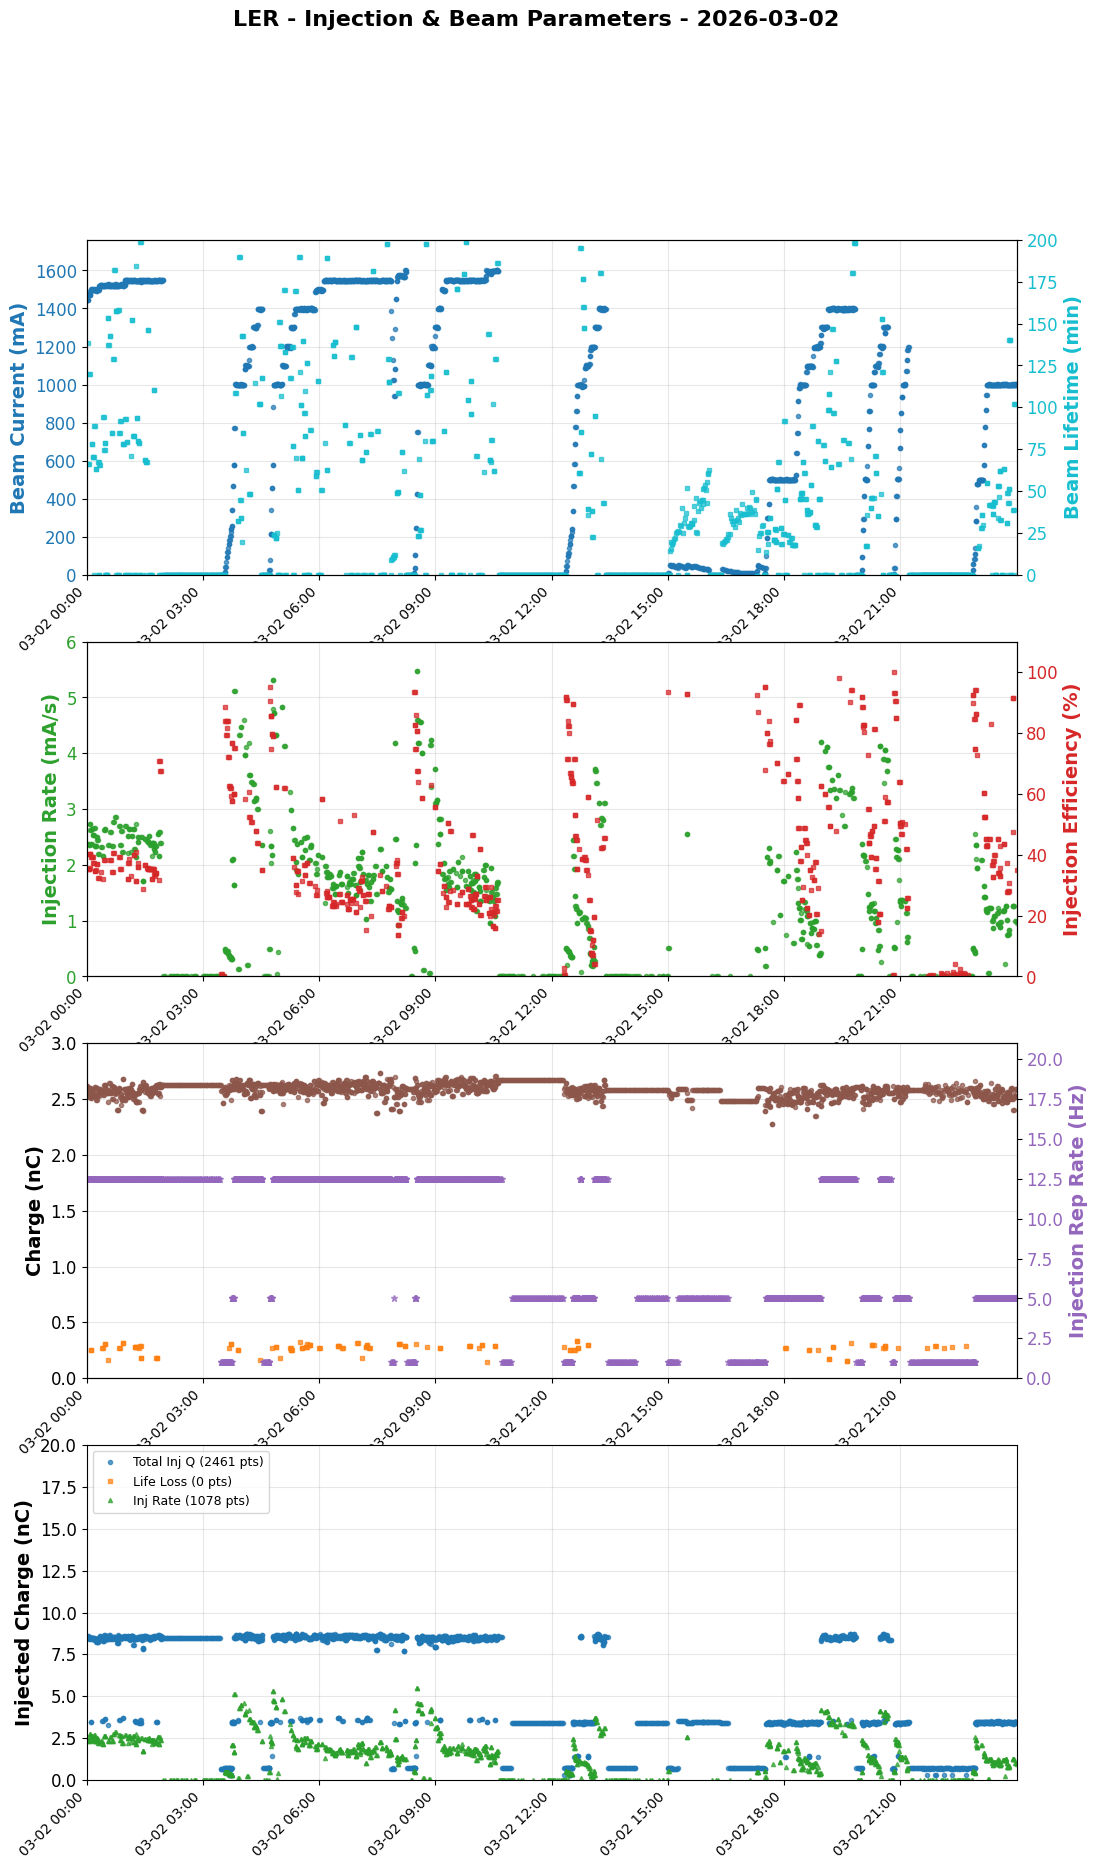


--- Generating HER Figure ---
  ✓ HER Figure 1: Beam Current + Beam Lifetime
  ✓ HER Figure 2: Injection Rate + Injection Efficiency
  ✓ HER Figure 3: Charge + Injection Rep Rate
  ✓ HER Figure 5: Total Inj Q + Life Loss + Inj Rate + Inj Loss Q


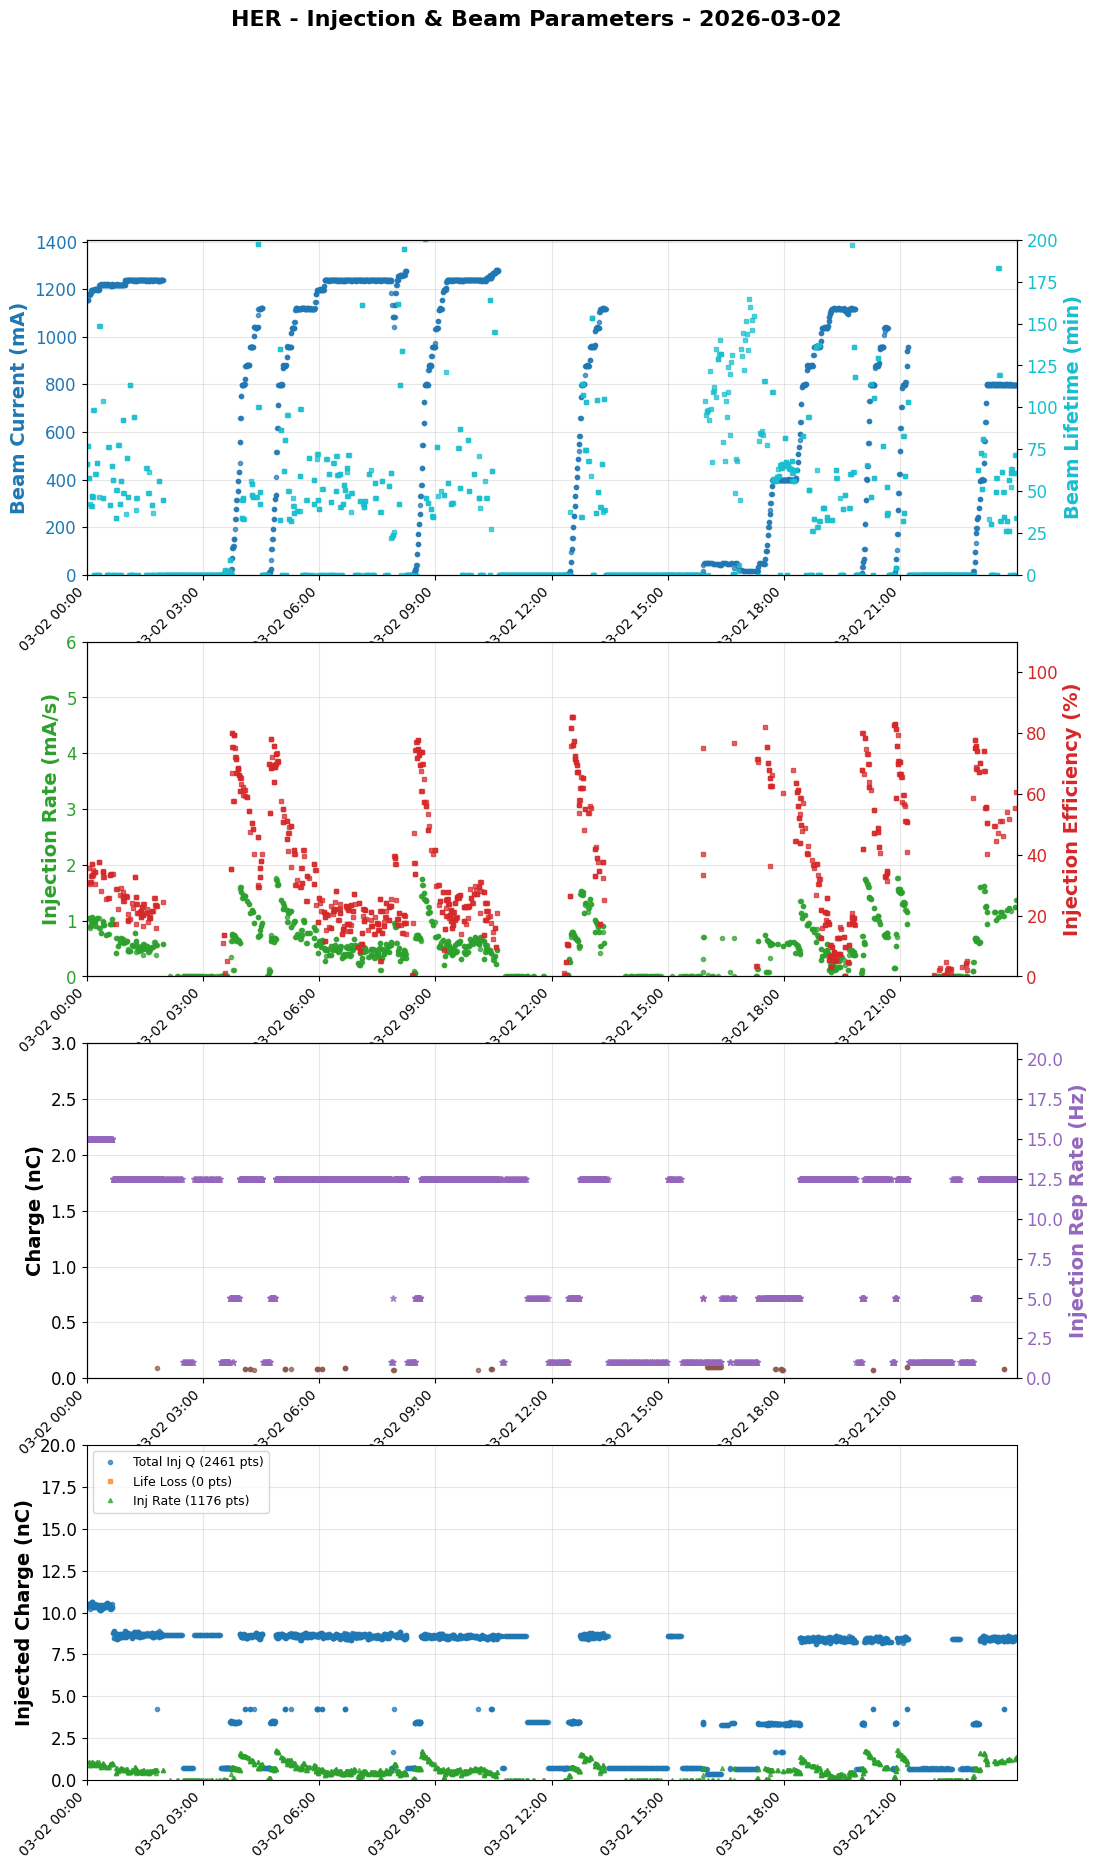


✓ Figures saved to /Users/xylu/Desktop/Data/acoustic_vpp/daily_plots/


In [103]:

if machine_df_filtered is not None and len(machine_df_filtered) > 0:
    print(f"\n{'='*70}")
    print("Creating 7-panel daily plots for LER and HER")
    print(f"{'='*70}")
    
    # Debug: Show all columns to identify HER data
    all_cols = list(machine_df_filtered.columns)
    her_cols = [col for col in all_cols if 'HER' in col or 'B_' in col]
    print(f"\nAll columns: {all_cols}")
    print(f"\nHER/B_ related columns: {her_cols}")
    
    # Generate LER Figure
    if 'A_LER_Current_mA' in machine_df_filtered.columns:
        print("\n--- Generating LER Figure ---")
        fig_ler = create_ring_figure(machine_df_filtered, 'LER', ler_abort_today)
        plt.savefig(f"/Users/xylu/Desktop/Data/acoustic_vpp/daily_plots/{date_str}_LER_7panel.png",
                   dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("⚠ LER columns not found in machine data")
    
    # Generate HER Figure
    if 'A_HER_Current_mA' in machine_df_filtered.columns:
        print("\n--- Generating HER Figure ---")
        fig_her = create_ring_figure(machine_df_filtered, 'HER', her_abort_today)
        plt.savefig(f"/Users/xylu/Desktop/Data/acoustic_vpp/daily_plots/{date_str}_HER_7panel.png",
                   dpi=150, bbox_inches='tight')
        plt.show()
    else:
        print("⚠ HER columns not found in machine data")
        
    print(f"\n✓ Figures saved to /Users/xylu/Desktop/Data/acoustic_vpp/daily_plots/")
else:
    print("⚠ No machine data available for plotting")


In [104]:
# # AUTOMATIC BATCH PROCESSING: Generate daily plots with same filtering/calculations as Cell 3 and Cell 5
# import re
# import gc

# print("=" * 80)
# print("AUTOMATIC BATCH PROCESSING - Daily 8-Panel Machine Variables Plots")
# print("=" * 80)

# # Create output folders
# output_plot_folder = "/Users/xylu/Desktop/Data/acoustic_vpp/daily_plots"
# output_data_folder = "/Users/xylu/Desktop/Data/acoustic_vpp/daily_calculated_data"
# os.makedirs(output_plot_folder, exist_ok=True)
# os.makedirs(output_data_folder, exist_ok=True)
# print(f"\nOutput plot folder: {output_plot_folder}")
# print(f"Output data folder: {output_data_folder}")

# base_path = "/Users/xylu/Desktop/Data/acoustic_vpp/"
# machine_base_path = "/Users/xylu/Desktop/Data/Machine_Inj_BG_byDay"

# all_folders = [f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))]
# date_pattern = re.compile(r"^\d{8}$")
# date_folders = sorted([f for f in all_folders if date_pattern.match(f)])

# print(f"\nFound {len(date_folders)} date folders to process")

# # Load abort event data once
# abort_data_path = "/Users/xylu/Desktop/Data/Complete_LER_Event_Data_Analysis_Summary.xlsx"
# if os.path.exists(abort_data_path):
#     abort_df_all = pd.read_excel(abort_data_path)
#     abort_df_all["abort_datetime"] = pd.to_datetime(abort_df_all["Time"], format="%m/%d/%y %H:%M", errors="coerce")
#     abort_df_all = abort_df_all.dropna(subset=["abort_datetime"])
#     print(f"✓ Loaded {len(abort_df_all)} total abort events from Excel")
# else:
#     print(f"⚠ Abort data file not found: {abort_data_path}")
#     abort_df_all = None

# print("\n" + "=" * 80)
# print("Processing dates...")
# print("=" * 80)


# def read_acoustic_for_day(csv_files_auto, start_time_obj_auto, end_time_obj_auto):
#     daily_chunks = []
#     for csv_file in csv_files_auto:
#         try:
#             df_temp = pd.read_csv(csv_file)
#             if "time_datetime" not in df_temp.columns:
#                 continue

#             df_temp["time_datetime"] = pd.to_datetime(df_temp["time_datetime"], errors="coerce")
#             df_temp = df_temp.dropna(subset=["time_datetime"])

#             mask_local = (df_temp["time_datetime"] >= start_time_obj_auto) & (df_temp["time_datetime"] <= end_time_obj_auto)
#             df_temp = df_temp.loc[mask_local, [c for c in ["time_datetime", "vpp_volts"] if c in df_temp.columns]]

#             if len(df_temp) > 0:
#                 daily_chunks.append(df_temp)
#         except Exception as e:
#             print(f"  ✗ Error reading acoustic file {os.path.basename(csv_file)}: {e}")
#             continue

#     if not daily_chunks:
#         return pd.DataFrame()

#     out_df = pd.concat(daily_chunks, ignore_index=True)
#     out_df = out_df.sort_values("time_datetime").drop_duplicates(subset=["time_datetime"], keep="last").reset_index(drop=True)
#     return out_df


# def read_machine_for_day(machine_csv_files_auto, start_time_obj_auto, end_time_obj_auto):
#     machine_chunks = []
#     for csv_file in machine_csv_files_auto:
#         try:
#             df_temp = pd.read_csv(csv_file)

#             if "#date" in df_temp.columns:
#                 df_temp["#date"] = pd.to_datetime(df_temp["#date"], errors="coerce")
#                 df_temp.rename(columns={"#date": "time_datetime"}, inplace=True)
#             elif "Timestamp" in df_temp.columns:
#                 df_temp["Timestamp"] = pd.to_datetime(df_temp["Timestamp"], errors="coerce")
#                 df_temp.rename(columns={"Timestamp": "time_datetime"}, inplace=True)
#             else:
#                 continue

#             df_temp = df_temp.dropna(subset=["time_datetime"])
#             mask_local = (df_temp["time_datetime"] >= start_time_obj_auto) & (df_temp["time_datetime"] <= end_time_obj_auto)
#             df_temp = df_temp.loc[mask_local]

#             if len(df_temp) > 0:
#                 machine_chunks.append(df_temp)
#         except Exception as e:
#             print(f"  ✗ Error reading machine file {os.path.basename(csv_file)}: {e}")
#             continue

#     if not machine_chunks:
#         return pd.DataFrame()

#     out_df = pd.concat(machine_chunks, ignore_index=True)
#     out_df = out_df.sort_values("time_datetime").drop_duplicates(subset=["time_datetime"], keep="last").reset_index(drop=True)
#     out_df.rename(columns=get_friendly_name, inplace=True)
#     return out_df


# # Process each date
# for date_idx, date_str_auto in enumerate(date_folders, start=1):
#     print(f"\n[{date_str_auto}] Processing ({date_idx}/{len(date_folders)})...")

#     start_time_obj_auto = datetime.strptime(date_str_auto + "000000", "%Y%m%d%H%M%S")
#     end_time_obj_auto = datetime.strptime(date_str_auto + "235959", "%Y%m%d%H%M%S")

#     date_folder_auto = os.path.join(base_path, date_str_auto)
#     csv_files_auto = sorted(glob.glob(os.path.join(date_folder_auto, f"{date_str_auto}*.csv")))
#     if len(csv_files_auto) == 0:
#         print("  ⚠ No acoustic CSV files found, skipping")
#         continue

#     mmdd_auto = date_str_auto[4:8]
#     machine_folder_auto = os.path.join(machine_base_path, mmdd_auto)
#     if not os.path.exists(machine_folder_auto):
#         print(f"  ⚠ Machine folder not found: {machine_folder_auto}, skipping")
#         continue

#     machine_csv_files_auto = sorted(glob.glob(os.path.join(machine_folder_auto, "*.csv")))
#     if len(machine_csv_files_auto) == 0:
#         print("  ⚠ No machine CSV files found, skipping")
#         continue

#     try:
#         filtered_df_auto = read_acoustic_for_day(csv_files_auto, start_time_obj_auto, end_time_obj_auto)
#         machine_df_filtered_auto = read_machine_for_day(machine_csv_files_auto, start_time_obj_auto, end_time_obj_auto)

#         if len(filtered_df_auto) == 0 or len(machine_df_filtered_auto) == 0:
#             print("  ⚠ Missing required data for plots, skipping")
#             continue

#         print(f"  ✓ Loaded {len(filtered_df_auto)} acoustic samples")
#         print(f"  ✓ Loaded {len(machine_df_filtered_auto)} machine data samples")

#         if "A_BM_Inj_Rate_mAps" in machine_df_filtered_auto.columns:
#             mask_inj_positive_auto = machine_df_filtered_auto["A_BM_Inj_Rate_mAps"].notna() & (machine_df_filtered_auto["A_BM_Inj_Rate_mAps"] >= 0)
#             inj_rate_positive_auto = machine_df_filtered_auto.loc[mask_inj_positive_auto, ["time_datetime", "A_BM_Inj_Rate_mAps"]].copy()
#             inj_rate_positive_times_auto = inj_rate_positive_auto["time_datetime"]
#             inj_rate_positive_values_auto = inj_rate_positive_auto["A_BM_Inj_Rate_mAps"].values
#         else:
#             inj_rate_positive_times_auto = pd.Series([], dtype="datetime64[ns]")
#             inj_rate_positive_values_auto = np.array([])

#         if "A_INJ_Effi" in machine_df_filtered_auto.columns:
#             mask_effi_nonzero_auto = machine_df_filtered_auto["A_INJ_Effi"].notna() & (machine_df_filtered_auto["A_INJ_Effi"] != 0)
#             effi_nonzero_auto = machine_df_filtered_auto.loc[mask_effi_nonzero_auto, ["time_datetime", "A_INJ_Effi"]].copy()
#             effi_nonzero_times_auto = effi_nonzero_auto["time_datetime"]
#             effi_nonzero_values_auto = effi_nonzero_auto["A_INJ_Effi"].values
#         else:
#             effi_nonzero_times_auto = pd.Series([], dtype="datetime64[ns]")
#             effi_nonzero_values_auto = np.array([])

#         if abort_df_all is not None:
#             abort_date_start_auto = datetime.strptime(date_str_auto, "%Y%m%d").replace(hour=0, minute=0, second=0)
#             abort_date_end_auto = abort_date_start_auto + timedelta(days=1)
#             abort_mask_auto = (abort_df_all["abort_datetime"] >= abort_date_start_auto) & (abort_df_all["abort_datetime"] < abort_date_end_auto)
#             abort_today_auto = abort_df_all.loc[abort_mask_auto].copy()
#         else:
#             abort_today_auto = None

#         fig, (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8) = plt.subplots(8, 1, figsize=(12, 22))
#         date_formatted_auto = datetime.strptime(date_str_auto, "%Y%m%d").strftime("%Y-%m-%d")
#         fig.suptitle(f"Acoustic, current, injection - {date_formatted_auto}", fontsize=12, fontweight="bold", y=0.995)

#         # ===== FIGURE 1: Vpp + Beam Current =====
#         if "A_BM_Current_mA" in machine_df_filtered_auto.columns and "vpp_volts" in filtered_df_auto.columns:
#             mask_current_auto = machine_df_filtered_auto["A_BM_Current_mA"].notna()
#             valid_times_current_auto = machine_df_filtered_auto.loc[mask_current_auto, "time_datetime"]
#             valid_current_auto = machine_df_filtered_auto.loc[mask_current_auto, "A_BM_Current_mA"]

#             color_vpp = "tab:blue"
#             ax1.set_ylabel("Bottom Acoustic Vpp (V)", color=color_vpp, fontsize=14, fontweight="bold")
#             ax1.plot(filtered_df_auto["time_datetime"], filtered_df_auto["vpp_volts"],
#                      linewidth=2.5, color=color_vpp, alpha=0.7, label=f"CH3 Vpp ({len(filtered_df_auto)} pts)")
#             ax1.tick_params(axis="y", labelcolor=color_vpp, labelsize=12)
#             ax1.set_ylim(0, 18)
#             ax1.grid(True, alpha=0.3)

#             ax1_right = ax1.twinx()
#             color_current = "darkorange"
#             ax1_right.set_ylabel("Beam Current (mA)", color=color_current, fontsize=14, fontweight="bold")
#             ax1_right.plot(valid_times_current_auto, valid_current_auto,
#                            linewidth=2.5, color=color_current, alpha=0.7, label=f"Beam Current ({len(valid_current_auto)} pts)")
#             ax1_right.tick_params(axis="y", labelcolor=color_current, labelsize=12)
#             ax1_right.set_ylim(0, 1700)

#         # ===== FIGURE 2: Injection Rate + Injection Efficiency =====
#         if len(inj_rate_positive_values_auto) > 0 and len(effi_nonzero_values_auto) > 0:
#             color_inj_rate = "tab:green"
#             ax2.set_ylabel("Injection Rate (mA/s)", color=color_inj_rate, fontsize=14, fontweight="bold")
#             ax2.plot(inj_rate_positive_times_auto, inj_rate_positive_values_auto,
#                      linewidth=0, marker="o", markersize=3, color=color_inj_rate, alpha=0.7,
#                      label=f"Inj Rate (positive: {len(inj_rate_positive_values_auto)} pts)")
#             ax2.tick_params(axis="y", labelcolor=color_inj_rate, labelsize=12)
#             ax2.set_ylim(0, 6)
#             ax2.grid(True, alpha=0.3)

#             ax2_right = ax2.twinx()
#             color_effi = "tab:red"
#             ax2_right.set_ylabel("Injection efficiency (%)", color=color_effi, fontsize=14, fontweight="bold")
#             ax2_right.plot(effi_nonzero_times_auto, effi_nonzero_values_auto,
#                            linewidth=0, marker="s", markersize=3, color=color_effi, alpha=0.7,
#                            label=f"Efficiency (non-zero: {len(effi_nonzero_values_auto)} pts)")
#             ax2_right.tick_params(axis="y", labelcolor=color_effi, labelsize=12)
#             ax2_right.set_ylim(0, 110)

#         # ===== FIGURE 3: Charge + Injection Rep Rate =====
#         valid_times_charge_auto = pd.Series([], dtype="datetime64[ns]")
#         valid_charge_auto = np.array([])
#         valid_times_rep_auto = pd.Series([], dtype="datetime64[ns]")
#         valid_rep_auto = np.array([])
#         if "A_Qep_BT_end_nC" in machine_df_filtered_auto.columns and "A_INJ_Rep_ep_Hz" in machine_df_filtered_auto.columns:
#             mask_charge_auto = machine_df_filtered_auto["A_Qep_BT_end_nC"].notna()
#             valid_times_charge_auto = machine_df_filtered_auto.loc[mask_charge_auto, "time_datetime"]
#             valid_charge_auto = machine_df_filtered_auto.loc[mask_charge_auto, "A_Qep_BT_end_nC"]

#             mask_rep_auto = machine_df_filtered_auto["A_INJ_Rep_ep_Hz"].notna()
#             valid_times_rep_auto = machine_df_filtered_auto.loc[mask_rep_auto, "time_datetime"]
#             valid_rep_auto = machine_df_filtered_auto.loc[mask_rep_auto, "A_INJ_Rep_ep_Hz"]

#             color_charge = "tab:brown"
#             ax3.set_ylabel("Charge BT end (nC)", color=color_charge, fontsize=14, fontweight="bold")
#             ax3.plot(valid_times_charge_auto, valid_charge_auto,
#                      linewidth=0, marker="o", color=color_charge, alpha=0.7, label=f"Charge ({len(valid_charge_auto)} pts)")
#             ax3.tick_params(axis="y", labelcolor=color_charge, labelsize=12)
#             ax3.set_ylim(0, 3)
#             ax3.grid(True, alpha=0.3)

#             ax3_right = ax3.twinx()
#             color_rep = "tab:purple"
#             ax3_right.set_ylabel("Injection Rep Rate (Hz)", color=color_rep, fontsize=14, fontweight="bold")
#             ax3_right.plot(valid_times_rep_auto, valid_rep_auto,
#                            linewidth=0, marker="*", color=color_rep, alpha=0.7, label=f"Rep Rate ({len(valid_rep_auto)} pts)")
#             ax3_right.tick_params(axis="y", labelcolor=color_rep, labelsize=12)
#             ax3_right.set_ylim(0, 21)
#         ax3.set_xlabel("Time", fontsize=14, fontweight="bold")

#         # ===== FIGURE 4: Total Loss (Effi) + Life Loss + Inj. Loss (Effi) =====
#         valid_times_total_loss_effi_auto = pd.Series([], dtype="datetime64[ns]")
#         valid_total_loss_effi_auto = np.array([])
#         if len(effi_nonzero_values_auto) > 0 and len(inj_rate_positive_values_auto) > 0:
#             df_matched_auto = pd.DataFrame({"time_datetime": effi_nonzero_times_auto, "efficiency": effi_nonzero_values_auto})
#             df_inj_auto = pd.DataFrame({"time_datetime": inj_rate_positive_times_auto, "inj_rate": inj_rate_positive_values_auto})
#             df_matched_auto = pd.merge(df_matched_auto, df_inj_auto, on="time_datetime", how="inner")
#             if len(df_matched_auto) > 0:
#                 effi_frac_auto = df_matched_auto["efficiency"].values / 100.0
#                 df_matched_auto["total_loss_effi"] = (1 - effi_frac_auto) / effi_frac_auto * df_matched_auto["inj_rate"].values
#                 df_matched_valid_auto = df_matched_auto[df_matched_auto["total_loss_effi"].notna()].copy()
#                 valid_times_total_loss_effi_auto = df_matched_valid_auto["time_datetime"]
#                 valid_total_loss_effi_auto = df_matched_valid_auto["total_loss_effi"].values

#         valid_times_life_loss_auto = pd.Series([], dtype="datetime64[ns]")
#         valid_life_loss_auto = np.array([])
#         if "A_BM_Current_mA" in machine_df_filtered_auto.columns and "A_BM_Lifetime_min" in machine_df_filtered_auto.columns:
#             mask_current_life_auto = machine_df_filtered_auto["A_BM_Current_mA"].notna() & machine_df_filtered_auto["A_BM_Lifetime_min"].notna()
#             mask_current_life_auto = mask_current_life_auto & (machine_df_filtered_auto["A_BM_Lifetime_min"] > 0)
#             valid_times_life_loss_auto = machine_df_filtered_auto.loc[mask_current_life_auto, "time_datetime"]
#             valid_current_life_auto = machine_df_filtered_auto.loc[mask_current_life_auto, "A_BM_Current_mA"]
#             valid_lifetime_auto = machine_df_filtered_auto.loc[mask_current_life_auto, "A_BM_Lifetime_min"]
#             valid_life_loss_auto = (valid_current_life_auto / valid_lifetime_auto / 60.0).values

#         valid_times_inj_loss_effi_auto = pd.Series([], dtype="datetime64[ns]")
#         valid_inj_loss_effi_auto = np.array([])
#         if len(valid_times_total_loss_effi_auto) > 0 and len(valid_times_life_loss_auto) > 0:
#             df_total_effi_auto = pd.DataFrame({"time_datetime": valid_times_total_loss_effi_auto, "total_loss_effi": valid_total_loss_effi_auto})
#             df_life_auto = pd.DataFrame({"time_datetime": valid_times_life_loss_auto, "life_loss": valid_life_loss_auto})
#             df_inj_loss_effi_auto = pd.merge(df_total_effi_auto, df_life_auto, on="time_datetime", how="inner")
#             if len(df_inj_loss_effi_auto) > 0:
#                 df_inj_loss_effi_auto["inj_loss_effi"] = df_inj_loss_effi_auto["total_loss_effi"] - df_inj_loss_effi_auto["life_loss"]
#                 valid_times_inj_loss_effi_auto = df_inj_loss_effi_auto["time_datetime"]
#                 valid_inj_loss_effi_auto = df_inj_loss_effi_auto["inj_loss_effi"].values

#         ax4.set_ylabel("Loss Rate (mA/s)", fontsize=14, fontweight="bold")
#         ax4.tick_params(axis="y", labelsize=12)
#         ax4.grid(True, alpha=0.3)
#         ax4.plot(valid_times_total_loss_effi_auto, valid_total_loss_effi_auto,
#                  linewidth=0, marker="o", markersize=3, color="tab:green", alpha=0.7,
#                  label=f"Total Loss (Effi) ({len(valid_total_loss_effi_auto)} pts)")
#         ax4.plot(valid_times_life_loss_auto, valid_life_loss_auto,
#                  linewidth=0, marker="s", markersize=3, color="tab:orange", alpha=0.7,
#                  label=f"Life Loss ({len(valid_life_loss_auto)} pts)")
#         if len(valid_inj_loss_effi_auto) > 0:
#             ax4.plot(valid_times_inj_loss_effi_auto, valid_inj_loss_effi_auto,
#                      linewidth=0, marker="*", markersize=3, color="tab:red", alpha=0.7,
#                      label=f"Inj. Loss (Effi) ({len(valid_inj_loss_effi_auto)} pts)")
#         ax4.legend(loc="upper left", fontsize=10)
#         ax4.set_xlabel("Time", fontsize=14, fontweight="bold")
#         ax4.set_ylim(0, 10)

#         # ===== FIGURE 5: Beam Lifetime + Beam Current =====
#         valid_times_lifetime_data_auto = pd.Series([], dtype="datetime64[ns]")
#         valid_lifetime_data_auto = np.array([])
#         valid_times_current_fig5_auto = pd.Series([], dtype="datetime64[ns]")
#         valid_current_fig5_auto = np.array([])
#         if "A_BM_Lifetime_min" in machine_df_filtered_auto.columns and "A_BM_Current_mA" in machine_df_filtered_auto.columns:
#             mask_lifetime_auto = machine_df_filtered_auto["A_BM_Lifetime_min"].notna() & (machine_df_filtered_auto["A_BM_Lifetime_min"] > 0)
#             valid_times_lifetime_data_auto = machine_df_filtered_auto.loc[mask_lifetime_auto, "time_datetime"]
#             valid_lifetime_data_auto = machine_df_filtered_auto.loc[mask_lifetime_auto, "A_BM_Lifetime_min"]

#             mask_current_fig5_auto = machine_df_filtered_auto["A_BM_Current_mA"].notna()
#             valid_times_current_fig5_auto = machine_df_filtered_auto.loc[mask_current_fig5_auto, "time_datetime"]
#             valid_current_fig5_auto = machine_df_filtered_auto.loc[mask_current_fig5_auto, "A_BM_Current_mA"]

#             color_lifetime = "tab:cyan"
#             ax5.set_ylabel("Beam Lifetime (min)", color=color_lifetime, fontsize=14, fontweight="bold")
#             ax5.plot(valid_times_lifetime_data_auto, valid_lifetime_data_auto,
#                      linewidth=0, marker="o", markersize=3, color=color_lifetime, alpha=0.7,
#                      label=f"Lifetime ({len(valid_lifetime_data_auto)} pts)")
#             ax5.tick_params(axis="y", labelcolor=color_lifetime, labelsize=12)
#             ax5.grid(True, alpha=0.3)
#             ax5.set_ylim(0, 200)

#             ax5_right = ax5.twinx()
#             color_current_fig5 = "darkorange"
#             ax5_right.set_ylabel("Beam Current (mA)", color=color_current_fig5, fontsize=14, fontweight="bold")
#             ax5_right.plot(valid_times_current_fig5_auto, valid_current_fig5_auto,
#                            linewidth=2.5, color=color_current_fig5, alpha=0.7,
#                            label=f"Current ({len(valid_current_fig5_auto)} pts)")
#             ax5_right.tick_params(axis="y", labelcolor=color_current_fig5, labelsize=12)
#             ax5_right.set_ylim(0, 1700)
#         ax5.set_xlabel("Time", fontsize=14, fontweight="bold")

#         # ===== FIGURE 6: Total Inj (Q) + Life Loss + Inj Rate + Inj. Loss (Q) =====
#         frev = 99.39e3
#         # bunch_number = 1 if start_time_obj_auto < pd.Timestamp('2026-01-30 20:00:00') else 2
#         valid_times_total_inj_q_auto = pd.Series([], dtype="datetime64[ns]")
#         valid_total_inj_q_auto = np.array([])
#         if "A_INJ_Rep_ep_Hz" in machine_df_filtered_auto.columns and "A_Qep_BT_end_nC" in machine_df_filtered_auto.columns:
#             mask_total_inj_auto = machine_df_filtered_auto["A_INJ_Rep_ep_Hz"].notna() & machine_df_filtered_auto["A_Qep_BT_end_nC"].notna()
#             if mask_total_inj_auto.any():
#                 df_total_inj_auto = machine_df_filtered_auto.loc[mask_total_inj_auto, ["time_datetime", "A_INJ_Rep_ep_Hz", "A_Qep_BT_end_nC"]].copy()
#                 df_total_inj_auto["total_inj_q"] = df_total_inj_auto["A_INJ_Rep_ep_Hz"].values * frev * df_total_inj_auto["A_Qep_BT_end_nC"].values * 1e-6 * bunch_number
#                 valid_times_total_inj_q_auto = df_total_inj_auto["time_datetime"]
#                 valid_total_inj_q_auto = df_total_inj_auto["total_inj_q"].values

#         valid_times_inj_rate_fig6_auto = inj_rate_positive_times_auto
#         valid_inj_rate_fig6_auto = inj_rate_positive_values_auto

#         valid_times_inj_loss_q_auto = pd.Series([], dtype="datetime64[ns]")
#         valid_inj_loss_q_auto = np.array([])
#         if len(valid_times_total_inj_q_auto) > 0 and len(valid_times_life_loss_auto) > 0 and len(valid_times_inj_rate_fig6_auto) > 0:
#             df_total_q_auto = pd.DataFrame({"time_datetime": valid_times_total_inj_q_auto, "total_inj_q": valid_total_inj_q_auto})
#             df_life_auto = pd.DataFrame({"time_datetime": valid_times_life_loss_auto, "life_loss": valid_life_loss_auto})
#             df_inj_rate_auto = pd.DataFrame({"time_datetime": valid_times_inj_rate_fig6_auto, "inj_rate": valid_inj_rate_fig6_auto})
#             df_inj_loss_q_auto = pd.merge(df_total_q_auto, df_life_auto, on="time_datetime", how="inner")
#             df_inj_loss_q_auto = pd.merge(df_inj_loss_q_auto, df_inj_rate_auto, on="time_datetime", how="inner")
#             if len(df_inj_loss_q_auto) > 0:
#                 df_inj_loss_q_auto["inj_loss_q"] = df_inj_loss_q_auto["total_inj_q"] - df_inj_loss_q_auto["life_loss"] - df_inj_loss_q_auto["inj_rate"]
#                 df_inj_loss_q_auto = df_inj_loss_q_auto[df_inj_loss_q_auto["inj_rate"] >= 0]
#                 valid_times_inj_loss_q_auto = df_inj_loss_q_auto["time_datetime"]
#                 valid_inj_loss_q_auto = df_inj_loss_q_auto["inj_loss_q"].values

#         ax6.set_ylabel("Rate (mA/s)", fontsize=14, fontweight="bold")
#         ax6.tick_params(axis="y", labelsize=12)
#         ax6.grid(True, alpha=0.3)
#         ax6.plot(valid_times_total_inj_q_auto, valid_total_inj_q_auto,
#                  linewidth=0, marker="o", markersize=3, color="tab:blue", alpha=0.7,
#                  label=f"Total Inj (Q) ({len(valid_total_inj_q_auto)} pts)")
#         ax6.plot(valid_times_life_loss_auto, valid_life_loss_auto,
#                  linewidth=0, marker="s", markersize=3, color="tab:orange", alpha=0.7,
#                  label=f"Life Loss ({len(valid_life_loss_auto)} pts)")
#         ax6.plot(valid_times_inj_rate_fig6_auto, valid_inj_rate_fig6_auto,
#                  linewidth=0, marker="^", markersize=3, color="tab:green", alpha=0.7,
#                  label=f"Inj Rate ({len(valid_inj_rate_fig6_auto)} pts)")
#         if len(valid_inj_loss_q_auto) > 0:
#             ax6.plot(valid_times_inj_loss_q_auto, valid_inj_loss_q_auto,
#                      linewidth=0, marker="*", markersize=3, color="tab:red", alpha=0.7,
#                      label=f"Inj. Loss (Q) ({len(valid_inj_loss_q_auto)} pts)")
#         ax6.legend(loc="upper left", fontsize=10)
#         ax6.set_xlabel("Time", fontsize=14, fontweight="bold")
#         ax6.set_ylim(0, 10)

#         # ===== FIGURE 7: Imported Efficiency vs Calculated Efficiency =====
#         valid_times_effi_imported_auto = pd.Series([], dtype="datetime64[ns]")
#         valid_effi_imported_auto = np.array([])
#         if len(inj_rate_positive_values_auto) > 0 and "A_INJ_Effi" in machine_df_filtered_auto.columns:
#             mask_effi_imported_auto = machine_df_filtered_auto["A_INJ_Effi"].notna()
#             df_all_effi_imported_auto = pd.DataFrame({
#                 "time_datetime": machine_df_filtered_auto.loc[mask_effi_imported_auto, "time_datetime"],
#                 "effi_imported": machine_df_filtered_auto.loc[mask_effi_imported_auto, "A_INJ_Effi"].values,
#             })
#             df_all_effi_imported_auto = df_all_effi_imported_auto[df_all_effi_imported_auto["effi_imported"] != 0]
#             df_inj_pos_auto = pd.DataFrame({"time_datetime": inj_rate_positive_times_auto})
#             df_effi_merged_auto = pd.merge(df_inj_pos_auto, df_all_effi_imported_auto, on="time_datetime", how="inner")
#             if len(df_effi_merged_auto) > 0:
#                 valid_times_effi_imported_auto = df_effi_merged_auto["time_datetime"]
#                 valid_effi_imported_auto = df_effi_merged_auto["effi_imported"].values

#         valid_times_effi_calc_auto = pd.Series([], dtype="datetime64[ns]")
#         valid_effi_calc_auto = np.array([])
#         if len(inj_rate_positive_values_auto) > 0 and len(valid_times_total_inj_q_auto) > 0:
#             df_inj_rate_auto = pd.DataFrame({"time_datetime": valid_times_inj_rate_fig6_auto, "inj_rate": valid_inj_rate_fig6_auto})
#             df_total_auto = pd.DataFrame({"time_datetime": valid_times_total_inj_q_auto, "total_inj_q": valid_total_inj_q_auto})
#             df_effi_calc_auto = pd.merge(df_inj_rate_auto, df_total_auto, on="time_datetime", how="inner")
#             if len(df_effi_calc_auto) > 0:
#                 df_effi_calc_auto["effi_calc"] = (df_effi_calc_auto["inj_rate"] / df_effi_calc_auto["total_inj_q"]) * 100.0
#                 valid_times_effi_calc_auto = df_effi_calc_auto["time_datetime"]
#                 valid_effi_calc_auto = df_effi_calc_auto["effi_calc"].values

#         ax7.set_ylabel("Injection efficiency (%)", fontsize=14, fontweight="bold")
#         ax7.tick_params(axis="y", labelsize=12)
#         ax7.grid(True, alpha=0.3)
#         ax7.plot(valid_times_effi_imported_auto, valid_effi_imported_auto,
#                  linewidth=0, marker="o", markersize=3, color="tab:red", alpha=0.7,
#                  label=f"Imported ({len(valid_effi_imported_auto)} pts)")
#         ax7.plot(valid_times_effi_calc_auto, valid_effi_calc_auto,
#                  linewidth=0, marker="*", markersize=3, color="tab:blue", alpha=0.7,
#                  label=f"Calculated ({len(valid_effi_calc_auto)} pts)")
#         ax7.legend(loc="upper left", fontsize=10)
#         ax7.set_xlabel("Time", fontsize=14, fontweight="bold")
#         ax7.set_ylim(0, 110)

#         # ===== FIGURE 8: Inj. Loss (Effi) vs Inj. Loss (Q) =====
#         ax8.set_ylabel("Injection Loss (mA/s)", fontsize=14, fontweight="bold")
#         ax8.tick_params(axis="y", labelsize=12)
#         ax8.grid(True, alpha=0.3)
#         ax8.plot(valid_times_inj_loss_effi_auto, valid_inj_loss_effi_auto,
#                  linewidth=0, marker="o", markersize=3, color="tab:red", alpha=0.7,
#                  label=f"Inj. Loss (Effi) ({len(valid_inj_loss_effi_auto)} pts)")
#         if len(valid_inj_loss_q_auto) > 0:
#             ax8.plot(valid_times_inj_loss_q_auto, valid_inj_loss_q_auto,
#                      linewidth=0, marker="s", markersize=3, color="tab:blue", alpha=0.7,
#                      label=f"Inj. Loss (Q) ({len(valid_inj_loss_q_auto)} pts)")
#         ax8.legend(loc="upper left", fontsize=10)
#         ax8.set_xlabel("Time", fontsize=14, fontweight="bold")
#         ax8.set_ylim(0, 8)

#         if abort_today_auto is not None and len(abort_today_auto) > 0:
#             sbl_beamloss_events_auto = abort_today_auto[abort_today_auto["Category"].isin(["SBL", "BeamLoss"])]
#             if len(sbl_beamloss_events_auto) > 0 and len(filtered_df_auto) > 0:
#                 day_min = filtered_df_auto["time_datetime"].min()
#                 day_max = filtered_df_auto["time_datetime"].max()
#                 for _, row in sbl_beamloss_events_auto.iterrows():
#                     abort_time = row["abort_datetime"]
#                     if day_min <= abort_time <= day_max:
#                         for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]:
#                             ax.axvline(x=abort_time, color="red", linestyle="--", linewidth=2, alpha=0.8, zorder=10)
#                             y_pos = ax.get_ylim()[1] * 0.95
#                             label_text = f"{row['Category']} {abort_time.strftime('%H:%M:%S')}"
#                             ax.text(abort_time, y_pos, label_text,
#                                     rotation=90, verticalalignment="top", horizontalalignment="right",
#                                     fontsize=10, color="darkred", fontweight="bold",
#                                     bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.0, edgecolor="darkred"))

#         for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]:
#             ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
#             ax.tick_params(axis="x", labelsize=12)
#             ax.set_xlim(start_time_obj_auto, end_time_obj_auto)

#         plt.xticks(rotation=45)
#         plt.tight_layout()

#         plot_filename = f"{date_str_auto}_machine_variables_panels.png"
#         plot_filepath = os.path.join(output_plot_folder, plot_filename)
#         plt.savefig(plot_filepath, dpi=150, bbox_inches="tight")
#         plt.close(fig)

#         # Export calculated series for this date
#         df_export_auto = pd.DataFrame({"time_datetime": machine_df_filtered_auto["time_datetime"]})
#         if len(valid_times_total_loss_effi_auto) > 0:
#             df_export_auto = pd.merge(df_export_auto, pd.DataFrame({"time_datetime": valid_times_total_loss_effi_auto, "total_loss_effi_mAps": valid_total_loss_effi_auto}), on="time_datetime", how="left")
#         if len(valid_times_life_loss_auto) > 0:
#             df_export_auto = pd.merge(df_export_auto, pd.DataFrame({"time_datetime": valid_times_life_loss_auto, "life_loss_mAps": valid_life_loss_auto}), on="time_datetime", how="left")
#         if len(valid_times_inj_loss_effi_auto) > 0:
#             df_export_auto = pd.merge(df_export_auto, pd.DataFrame({"time_datetime": valid_times_inj_loss_effi_auto, "inj_loss_effi_mAps": valid_inj_loss_effi_auto}), on="time_datetime", how="left")
#         if len(valid_times_total_inj_q_auto) > 0:
#             df_export_auto = pd.merge(df_export_auto, pd.DataFrame({"time_datetime": valid_times_total_inj_q_auto, "total_inj_q_mAps": valid_total_inj_q_auto}), on="time_datetime", how="left")
#         if len(valid_times_inj_rate_fig6_auto) > 0:
#             df_export_auto = pd.merge(df_export_auto, pd.DataFrame({"time_datetime": valid_times_inj_rate_fig6_auto, "inj_rate_positive_mAps": valid_inj_rate_fig6_auto}), on="time_datetime", how="left")
#         if len(valid_times_inj_loss_q_auto) > 0:
#             df_export_auto = pd.merge(df_export_auto, pd.DataFrame({"time_datetime": valid_times_inj_loss_q_auto, "inj_loss_q_mAps": valid_inj_loss_q_auto}), on="time_datetime", how="left")
#         if len(valid_times_effi_imported_auto) > 0:
#             df_export_auto = pd.merge(df_export_auto, pd.DataFrame({"time_datetime": valid_times_effi_imported_auto, "effi_imported_pct": valid_effi_imported_auto}), on="time_datetime", how="left")
#         if len(valid_times_effi_calc_auto) > 0:
#             df_export_auto = pd.merge(df_export_auto, pd.DataFrame({"time_datetime": valid_times_effi_calc_auto, "effi_calc_pct": valid_effi_calc_auto}), on="time_datetime", how="left")
#         df_export_auto = df_export_auto.drop_duplicates(subset=["time_datetime"]).sort_values("time_datetime").reset_index(drop=True)

#         export_filename = f"{date_str_auto}_calculated_series.csv"
#         export_filepath = os.path.join(output_data_folder, export_filename)
#         df_export_auto.to_csv(export_filepath, index=False)

#         print(f"  ✓ Saved plot: {plot_filename}")
#         print(f"  ✓ Saved data: {export_filename}")

#     except Exception as e:
#         print(f"  ✗ Error processing {date_str_auto}: {e}")

#     finally:
#         gc.collect()

# print("\n" + "=" * 80)
# print("BATCH PROCESSING COMPLETE!")
# print(f"All plots saved to: {output_plot_folder}")
# print(f"All calculated data saved to: {output_data_folder}")
# print("=" * 80)

In [105]:
# CELL 7: Machine-only data loading with separate LER and HER analyses

import os
import re
import glob
import gc
import pandas as pd
import numpy as np

print("=" * 80)
print("MACHINE DATA LOADING - SEPARATE LER AND HER")
print("=" * 80)

machine_base_path_corr = "/Users/xylu/Desktop/Data/Machine_Data_LER_HER_Acoustic/"

merged_data_by_date_ler = {}
merged_data_by_date_her = {}
all_merged_df_ler = pd.DataFrame()
all_merged_df_her = pd.DataFrame()

if not os.path.exists(machine_base_path_corr):
    print(f"⚠ Machine base path not found: {machine_base_path_corr}")
else:
    all_folders_corr = [
        f for f in os.listdir(machine_base_path_corr)
        if os.path.isdir(os.path.join(machine_base_path_corr, f))
    ]

    year_hint = date_str[:4] if "date_str" in globals() and len(date_str) >= 4 else "2026"
    mmdd_folders = sorted([f for f in all_folders_corr if re.match(r"^\d{4}$", f)])
    yyyymmdd_folders = sorted([f for f in all_folders_corr if re.match(r"^\d{8}$", f)])

    date_folders = []
    date_folders.extend(yyyymmdd_folders)
    date_folders.extend([f"{year_hint}{mmdd}" for mmdd in mmdd_folders])
    date_folders = sorted(set(date_folders))

    print(f"\nFound {len(date_folders)} date folders from machine data")

    if "pv_mapping" in globals() and isinstance(pv_mapping, list):
        pv_dict_local = {k: v for k, v in pv_mapping}
    else:
        pv_dict_local = {}

    frev = 99.39e3

    def build_ring_dataframe(machine_df_day, date_label, ring_name):
        if ring_name == "LER":
            current_col = "A_LER_Current_mA"
            lifetime_col = "A_LER_Lifetime_min"
            inj_rate_col = "A_LER_Inj_Rate_mAps"
            effi_col = "A_LER_Tot_INJ_Effi"
            rep_col = "A_LER_Rep_ep_Hz"
            charge_b1_col = "A_Q_LERB1_BT_end_nC"
            charge_b2_col = "A_Q_LERB2_BT_end_nC"
        else:
            current_col = "A_HER_Current_mA"
            lifetime_col = "A_HER_Lifetime_min"
            inj_rate_col = "A_HER_Inj_Rate_mAps"
            effi_col = "A_HER_Tot_INJ_Effi"
            rep_col = "A_HER_Rep_ep_Hz"
            charge_b1_col = "A_Q_HERB1_BT_end_nC"
            charge_b2_col = "A_Q_HERB2_BT_end_nC"

        required_raw_cols = [
            "time_datetime",
            current_col,
            lifetime_col,
            inj_rate_col,
            effi_col,
            rep_col,
            charge_b1_col,
            charge_b2_col,
        ]
        missing_raw = [col for col in required_raw_cols if col not in machine_df_day.columns]
        if missing_raw:
            print(f"[{date_label}] {ring_name} skipped (missing columns: {missing_raw})")
            return pd.DataFrame()

        ring_df = machine_df_day.copy()

        # Keep your prefilter logic, applied within each ring separately.
        rows_before = len(ring_df)
        pre_mask = (
            (ring_df[inj_rate_col] > 0)
            & (ring_df[effi_col] != 0)
            & ring_df[inj_rate_col].notna()
            & ring_df[effi_col].notna()
        )
        ring_df = ring_df.loc[pre_mask].copy()
        rows_after = len(ring_df)
        print(f"[{date_label}] {ring_name} prefilter kept {rows_after:,} / {rows_before:,} rows")

        ring_df["A_BM_Current_mA"] = ring_df[current_col]
        ring_df["A_BM_Lifetime_min"] = ring_df[lifetime_col]
        ring_df["A_BM_Inj_Rate_mAps"] = ring_df[inj_rate_col]
        ring_df["A_INJ_Effi"] = ring_df[effi_col]
        ring_df["A_INJ_Rep_ep_Hz"] = ring_df[rep_col]
        ring_df["charge_b1"] = ring_df[charge_b1_col]
        ring_df["charge_b2"] = ring_df[charge_b2_col]
        ring_df["charge_sum"] = ring_df["charge_b1"] + ring_df["charge_b2"]

        ring_df["life_loss"] = np.where(
            ring_df["A_BM_Current_mA"].notna()
            & ring_df["A_BM_Lifetime_min"].notna()
            & (ring_df["A_BM_Lifetime_min"] > 0),
            ring_df["A_BM_Current_mA"] / ring_df["A_BM_Lifetime_min"] / 60.0,
            np.nan,
        )

        ring_df["total_inj_q"] = np.where(
            ring_df["A_INJ_Rep_ep_Hz"].notna() & ring_df["charge_sum"].notna(),
            ring_df["A_INJ_Rep_ep_Hz"] * frev * ring_df["charge_sum"] * 1e-6,
            np.nan,
        )

        ring_df["inj_loss_q"] = np.where(
            ring_df["total_inj_q"].notna()
            & ring_df["life_loss"].notna()
            & ring_df["A_BM_Inj_Rate_mAps"].notna(),
            ring_df["total_inj_q"] - ring_df["life_loss"] - ring_df["A_BM_Inj_Rate_mAps"],
            np.nan,
        )

        # Only keep timestamps where all parameters for this ring are present.
        required_present_cols = [
            "time_datetime",
            "A_BM_Current_mA",
            "A_BM_Lifetime_min",
            "A_BM_Inj_Rate_mAps",
            "A_INJ_Effi",
            "A_INJ_Rep_ep_Hz",
            "charge_b1",
            "charge_b2",
            "charge_sum",
            "life_loss",
            "total_inj_q",
            "inj_loss_q",
        ]
        ring_df = ring_df.dropna(subset=required_present_cols).copy()

        for col in ring_df.columns:
            if col != "time_datetime" and pd.api.types.is_float_dtype(ring_df[col]):
                ring_df[col] = pd.to_numeric(ring_df[col], downcast="float")

        print(f"[{date_label}] {ring_name} final rows with complete parameters: {len(ring_df):,}")
        return ring_df

    for idx, date_str_corr in enumerate(date_folders, start=1):
        mmdd_corr = date_str_corr[4:8]
        folder_mmdd = os.path.join(machine_base_path_corr, mmdd_corr)
        folder_yyyymmdd = os.path.join(machine_base_path_corr, date_str_corr)

        if os.path.exists(folder_mmdd):
            machine_folder_corr = folder_mmdd
        elif os.path.exists(folder_yyyymmdd):
            machine_folder_corr = folder_yyyymmdd
        else:
            continue

        machine_csv_files_corr = sorted(glob.glob(os.path.join(machine_folder_corr, "*.csv")))
        if not machine_csv_files_corr:
            continue

        machine_data_list_corr = []
        for csv_file in machine_csv_files_corr:
            try:
                df_temp = pd.read_csv(csv_file)

                if "#date" in df_temp.columns:
                    df_temp["#date"] = pd.to_datetime(df_temp["#date"], errors="coerce")
                    df_temp.rename(columns={"#date": "time_datetime"}, inplace=True)
                elif "Timestamp" in df_temp.columns:
                    df_temp["Timestamp"] = pd.to_datetime(df_temp["Timestamp"], errors="coerce")
                    df_temp.rename(columns={"Timestamp": "time_datetime"}, inplace=True)
                elif "time_datetime" in df_temp.columns:
                    df_temp["time_datetime"] = pd.to_datetime(df_temp["time_datetime"], errors="coerce")
                else:
                    continue

                df_temp = df_temp.dropna(subset=["time_datetime"])
                machine_data_list_corr.append(df_temp)
            except Exception:
                continue

        if not machine_data_list_corr:
            continue

        machine_df_corr = pd.concat(machine_data_list_corr, ignore_index=True)
        machine_df_corr = machine_df_corr.sort_values("time_datetime").drop_duplicates(
            subset=["time_datetime"], keep="last"
        )
        machine_df_corr.columns = machine_df_corr.columns.str.strip()
        if pv_dict_local:
            machine_df_corr.rename(columns=lambda c: pv_dict_local.get(c, c), inplace=True)

        ler_df = build_ring_dataframe(machine_df_corr, date_str_corr, "LER")
        her_df = build_ring_dataframe(machine_df_corr, date_str_corr, "HER")

        merged_data_by_date_ler[date_str_corr] = ler_df
        merged_data_by_date_her[date_str_corr] = her_df

        del machine_data_list_corr, machine_df_corr, ler_df, her_df
        if idx % 3 == 0:
            gc.collect()

    print("\nCombining LER data from all dates...")
    if any(len(df) > 0 for df in merged_data_by_date_ler.values()):
        all_merged_df_ler = pd.concat(
            [df for df in merged_data_by_date_ler.values() if len(df) > 0],
            ignore_index=True,
        )
        print(f"Total combined LER data points: {len(all_merged_df_ler):,}")
    else:
        print("⚠ No LER merged data was created.")

    print("\nCombining HER data from all dates...")
    if any(len(df) > 0 for df in merged_data_by_date_her.values()):
        all_merged_df_her = pd.concat(
            [df for df in merged_data_by_date_her.values() if len(df) > 0],
            ignore_index=True,
        )
        print(f"Total combined HER data points: {len(all_merged_df_her):,}")
    else:
        print("⚠ No HER merged data was created.")

    print("\n✓ Separate machine-data loading complete.")

MACHINE DATA LOADING - SEPARATE LER AND HER

Found 45 date folders from machine data
[20260126] LER prefilter kept 56 / 1,899 rows
[20260126] LER final rows with complete parameters: 11
[20260126] HER prefilter kept 172 / 1,899 rows
[20260126] HER final rows with complete parameters: 2
[20260127] LER prefilter kept 319 / 1,972 rows
[20260127] LER final rows with complete parameters: 191
[20260127] HER prefilter kept 306 / 1,972 rows
[20260127] HER final rows with complete parameters: 58
[20260128] LER prefilter kept 673 / 1,986 rows
[20260128] LER final rows with complete parameters: 358
[20260128] HER prefilter kept 625 / 1,986 rows
[20260128] HER final rows with complete parameters: 162
[20260129] LER prefilter kept 603 / 1,888 rows
[20260129] LER final rows with complete parameters: 282
[20260129] HER prefilter kept 191 / 1,888 rows
[20260129] HER final rows with complete parameters: 78
[20260130] LER prefilter kept 380 / 1,930 rows
[20260130] LER final rows with complete parameters

In [106]:
# CELL: Daily Summary Dataset - separate LER and HER summaries

print("\n" + "=" * 80)
print("BUILDING DAILY SUMMARY DATASETS - LER AND HER")
print("=" * 80)

import subprocess
import sys
from datetime import timedelta

# Ensure openpyxl is installed
subprocess.check_call([sys.executable, "-m", "pip", "install", "openpyxl", "-q"])

HIGH_CURRENT_THRESHOLD = 500  # mA

ler_abort_data_path = "/Users/xylu/Desktop/Data/Database_Abort/Updated_LER_Event_Data_Analysis.csv"
her_abort_data_path = "/Users/xylu/Desktop/Data/Database_Abort/Complete_HER_Event_Data_Analysis_Summary.xlsx"

def load_abort_dataframe(file_path, ring_name):
    if not os.path.exists(file_path):
        print(f"⚠ {ring_name} abort data file not found: {file_path}")
        return None

    if file_path.endswith(".csv"):
        abort_df = pd.read_csv(file_path)
    else:
        abort_df = pd.read_excel(file_path)
    abort_df["abort_datetime"] = pd.to_datetime(
        abort_df["Time"], format="mixed", dayfirst=False, errors="coerce"
    )

    abort_df = abort_df.dropna(subset=["abort_datetime"]).copy()
    print(f"✓ Loaded {len(abort_df)} total {ring_name} abort events")
    if len(abort_df) > 0:
        print(f"  Date range: {abort_df['abort_datetime'].min()} to {abort_df['abort_datetime'].max()}")
    return abort_df

def integrate_metric_over_time(df, metric_col, default_dt_sec=np.nan):
    if metric_col not in df.columns:
        return np.nan

    metric_df = df[["time_datetime", metric_col]].dropna().sort_values("time_datetime")
    if len(metric_df) == 0:
        return np.nan

    if len(metric_df) == 1:
        if pd.notna(default_dt_sec) and default_dt_sec > 0:
            return float(metric_df[metric_col].iloc[0]) * default_dt_sec / 3600.0
        return np.nan

    x_hours = (
        metric_df["time_datetime"] - metric_df["time_datetime"].iloc[0]
    ).dt.total_seconds().to_numpy(dtype=float) / 3600.0
    y_vals = metric_df[metric_col].to_numpy(dtype=float)
    return float(np.trapezoid(y_vals, x_hours))

def build_daily_summary(merged_data_by_date_ring, abort_df_ring, ring_name):
    daily_summary_rows = []
    dates_to_analyze = sorted(merged_data_by_date_ring.keys())

    for date_label in dates_to_analyze:
        merged_df = merged_data_by_date_ring[date_label]

        if len(merged_df) == 0:
            continue

        high_current_mask = (
            merged_df["A_BM_Current_mA"].notna()
            & (merged_df["A_BM_Current_mA"] >= HIGH_CURRENT_THRESHOLD)
        )

        if high_current_mask.sum() == 0:
            continue

        high_current_df = merged_df.loc[high_current_mask].copy().sort_values("time_datetime")

        sbl_count = 0
        beamloss_count = 0

        if abort_df_ring is not None:
            abort_date_start = pd.to_datetime(date_label, format="%Y%m%d")
            abort_date_end = abort_date_start + timedelta(days=1)
            abort_mask = (
                (abort_df_ring["abort_datetime"] >= abort_date_start)
                & (abort_df_ring["abort_datetime"] < abort_date_end)
            )
            aborts_today = abort_df_ring.loc[abort_mask].copy()

            if len(aborts_today) > 0:
                sbl_mask = aborts_today["Category"].astype(str).str.contains("SBL", case=False, na=False)
                beam_mask = aborts_today["Category"].astype(str).str.contains(
                    "BeamLoss|Beam Loss|BML", case=False, na=False
                )
                sbl_count = int(sbl_mask.sum())
                beamloss_count = int(beam_mask.sum())

        hc_times = high_current_df["time_datetime"].sort_values()
        hc_sample_dt_sec = np.nan
        hc_exposure_hours = np.nan

        if len(hc_times) >= 2:
            dt_seconds = hc_times.diff().dt.total_seconds().dropna()
            dt_seconds = dt_seconds[dt_seconds > 0]
            if len(dt_seconds) > 0:
                hc_sample_dt_sec = dt_seconds.median()
                hc_exposure_hours = len(hc_times) * hc_sample_dt_sec / 3600.0

        total_aborts = sbl_count + beamloss_count
        if pd.notna(hc_exposure_hours) and hc_exposure_hours > 0:
            abort_rate_per_hc_hour = total_aborts / hc_exposure_hours
        else:
            abort_rate_per_hc_hour = np.nan

        summary_row = {
            "date": date_label,
            "ring": ring_name,
            "n_sbl_aborts": sbl_count,
            "n_beamloss_aborts": beamloss_count,
            "total_aborts": total_aborts,
            "n_hc_samples": int(high_current_mask.sum()),
            "hc_sample_dt_sec": hc_sample_dt_sec,
            "hc_exposure_hours": hc_exposure_hours,
            "abort_rate_per_hc_hour": abort_rate_per_hc_hour,
        }

        # High-current time-integrated metrics (left-column plots).
        summary_row["current_int_hc"] = integrate_metric_over_time(high_current_df, "A_BM_Current_mA", hc_sample_dt_sec)
        summary_row["inj_loss_q_int_hc"] = integrate_metric_over_time(high_current_df, "inj_loss_q", hc_sample_dt_sec)
        summary_row["total_inj_q_int_hc"] = integrate_metric_over_time(high_current_df, "total_inj_q", hc_sample_dt_sec)
        summary_row["life_loss_int_hc"] = integrate_metric_over_time(high_current_df, "life_loss", hc_sample_dt_sec)

        for acou_param in ["ACOU_Top_Vpp", "ACOU_BmLoss_Vpp", "ACOU_Btm_Vpp"]:
            if acou_param in high_current_df.columns:
                summary_row[f"{acou_param}_avg"] = high_current_df[acou_param].mean()
                summary_row[f"{acou_param}_std"] = high_current_df[acou_param].std()
            else:
                summary_row[f"{acou_param}_avg"] = np.nan
                summary_row[f"{acou_param}_std"] = np.nan

        for metric in ["inj_loss_q", "total_inj_q", "life_loss"]:
            if metric in high_current_df.columns:
                summary_row[f"{metric}_avg"] = high_current_df[metric].mean()
                summary_row[f"{metric}_std"] = high_current_df[metric].std()
            else:
                summary_row[f"{metric}_avg"] = np.nan
                summary_row[f"{metric}_std"] = np.nan

        for metric in ["A_BM_Inj_Rate_mAps", "A_INJ_Effi", "A_BM_Lifetime_min", "A_LUMI_30", "A_LUMI_SP_30"]:
            if metric in high_current_df.columns:
                summary_row[f"{metric}_avg"] = high_current_df[metric].mean()
                summary_row[f"{metric}_std"] = high_current_df[metric].std()
            else:
                summary_row[f"{metric}_avg"] = np.nan
                summary_row[f"{metric}_std"] = np.nan

        if "A_BM_Current_mA" in high_current_df.columns:
            summary_row["current_avg"] = high_current_df["A_BM_Current_mA"].mean()
            summary_row["current_std"] = high_current_df["A_BM_Current_mA"].std()
            summary_row["current_max"] = high_current_df["A_BM_Current_mA"].max()
        else:
            summary_row["current_avg"] = np.nan
            summary_row["current_std"] = np.nan
            summary_row["current_max"] = np.nan

        daily_summary_rows.append(summary_row)

    return pd.DataFrame(daily_summary_rows)

def print_summary(summary_df, ring_name):
    print("\n" + "-" * 80)
    print(f"{ring_name} DAILY SUMMARY")
    print("-" * 80)

    if summary_df.empty:
        print(f"⚠ No {ring_name} days passed the high-current selection.")
        return

    print(f"✓ Created {ring_name} daily summary dataset with {len(summary_df)} days")
    print(f"✓ Columns included: {len(summary_df.columns)} metrics")
    print(f"\nDate range: {summary_df['date'].min()} to {summary_df['date'].max()}")
    print(f"\nDataset shape: {summary_df.shape}")

    print(f"\n✓ {ring_name} Abort Summary:")
    print(f"  Total SBL Aborts: {summary_df['n_sbl_aborts'].sum():.0f}")
    print(f"  Total BeamLoss Aborts: {summary_df['n_beamloss_aborts'].sum():.0f}")
    print(f"  Total Aborts: {summary_df['total_aborts'].sum():.0f}")

    if "abort_rate_per_hc_hour" in summary_df.columns:
        valid_rates = summary_df["abort_rate_per_hc_hour"].dropna()
        if len(valid_rates) > 0:
            print(f"  Mean abort rate (per high-current hour): {valid_rates.mean():.3f}")
            print(f"  Median abort rate (per high-current hour): {valid_rates.median():.3f}")

    print(f"\n{ring_name} days with Aborts:")
    days_with_aborts = summary_df.loc[
        summary_df["total_aborts"] > 0,
        ["date", "n_sbl_aborts", "n_beamloss_aborts", "total_aborts", "abort_rate_per_hc_hour"],
    ]
    if len(days_with_aborts) > 0:
        print(days_with_aborts.to_string(index=False))
    else:
        print("  No aborts recorded during high current operation")

    print(f"\n✓ First few rows:")
    print(summary_df.head())

ler_abort_df_summary = load_abort_dataframe(ler_abort_data_path, "LER")
her_abort_df_summary = load_abort_dataframe(her_abort_data_path, "HER")

daily_summary_df_ler = build_daily_summary(
    merged_data_by_date_ler,
    ler_abort_df_summary,
    "LER",
)
daily_summary_df_her = build_daily_summary(
    merged_data_by_date_her,
    her_abort_df_summary,
    "HER",
)

print_summary(daily_summary_df_ler, "LER")
print_summary(daily_summary_df_her, "HER")

print("\n✓ Separate daily summary datasets are ready:")
print("  daily_summary_df_ler")
print("  daily_summary_df_her")
print("=" * 80)


BUILDING DAILY SUMMARY DATASETS - LER AND HER



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


✓ Loaded 196 total LER abort events
  Date range: 2026-01-26 17:17:59 to 2026-03-12 09:09:41
✓ Loaded 476 total HER abort events
  Date range: 2026-01-29 14:41:07 to 2026-03-12 15:04:36

--------------------------------------------------------------------------------
LER DAILY SUMMARY
--------------------------------------------------------------------------------
✓ Created LER daily summary dataset with 42 days
✓ Columns included: 38 metrics

Date range: 20260127 to 20260311

Dataset shape: (42, 38)

✓ LER Abort Summary:
  Total SBL Aborts: 36
  Total BeamLoss Aborts: 40
  Total Aborts: 76
  Mean abort rate (per high-current hour): 0.234
  Median abort rate (per high-current hour): 0.125

LER days with Aborts:
    date  n_sbl_aborts  n_beamloss_aborts  total_aborts  abort_rate_per_hc_hour
20260127             0                  2             2                0.366692
20260128             0                 10            10                0.867052
20260203             2                 


VISUALIZING DAILY SUMMARIES - LER AND HER


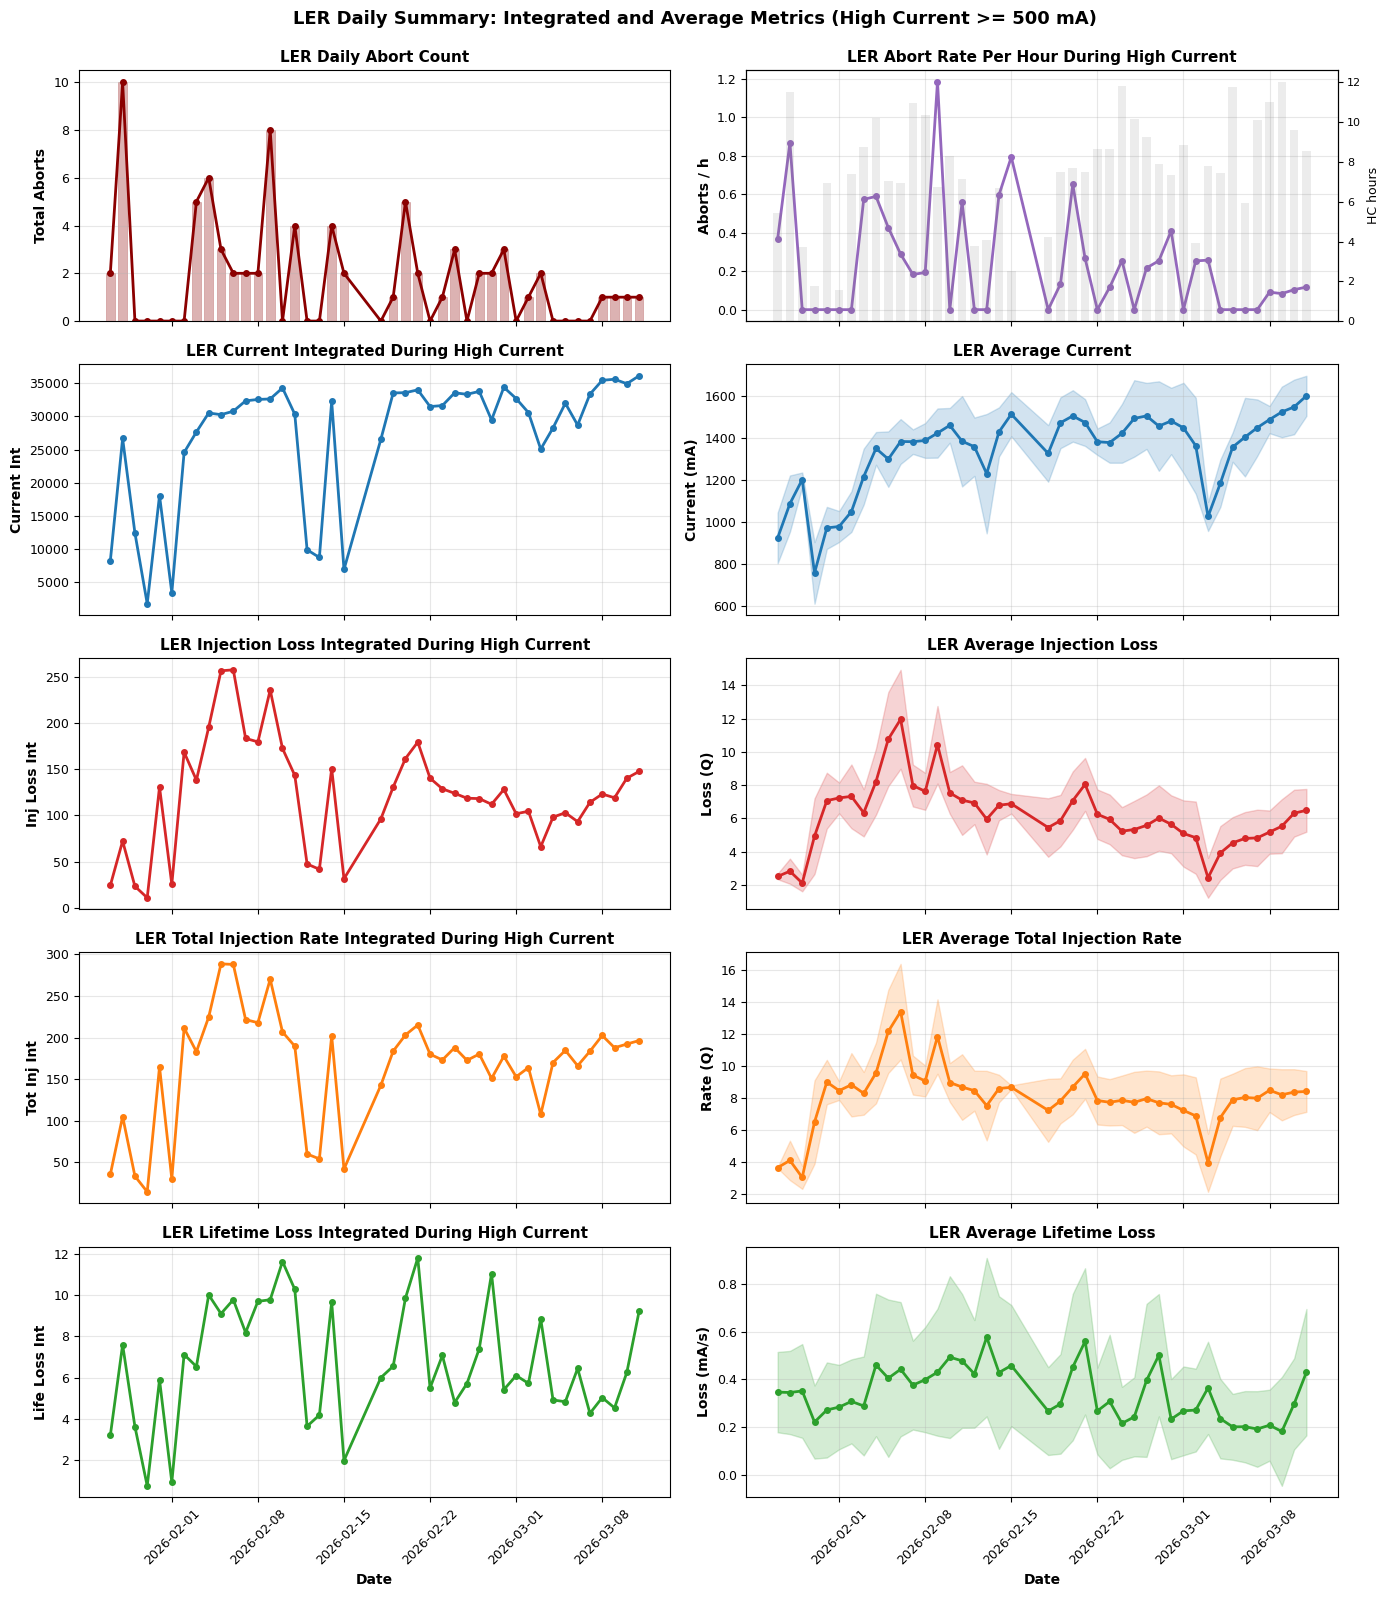


✓ LER visualization complete
  Total days analyzed: 42
  Date range: 20260127 to 20260311


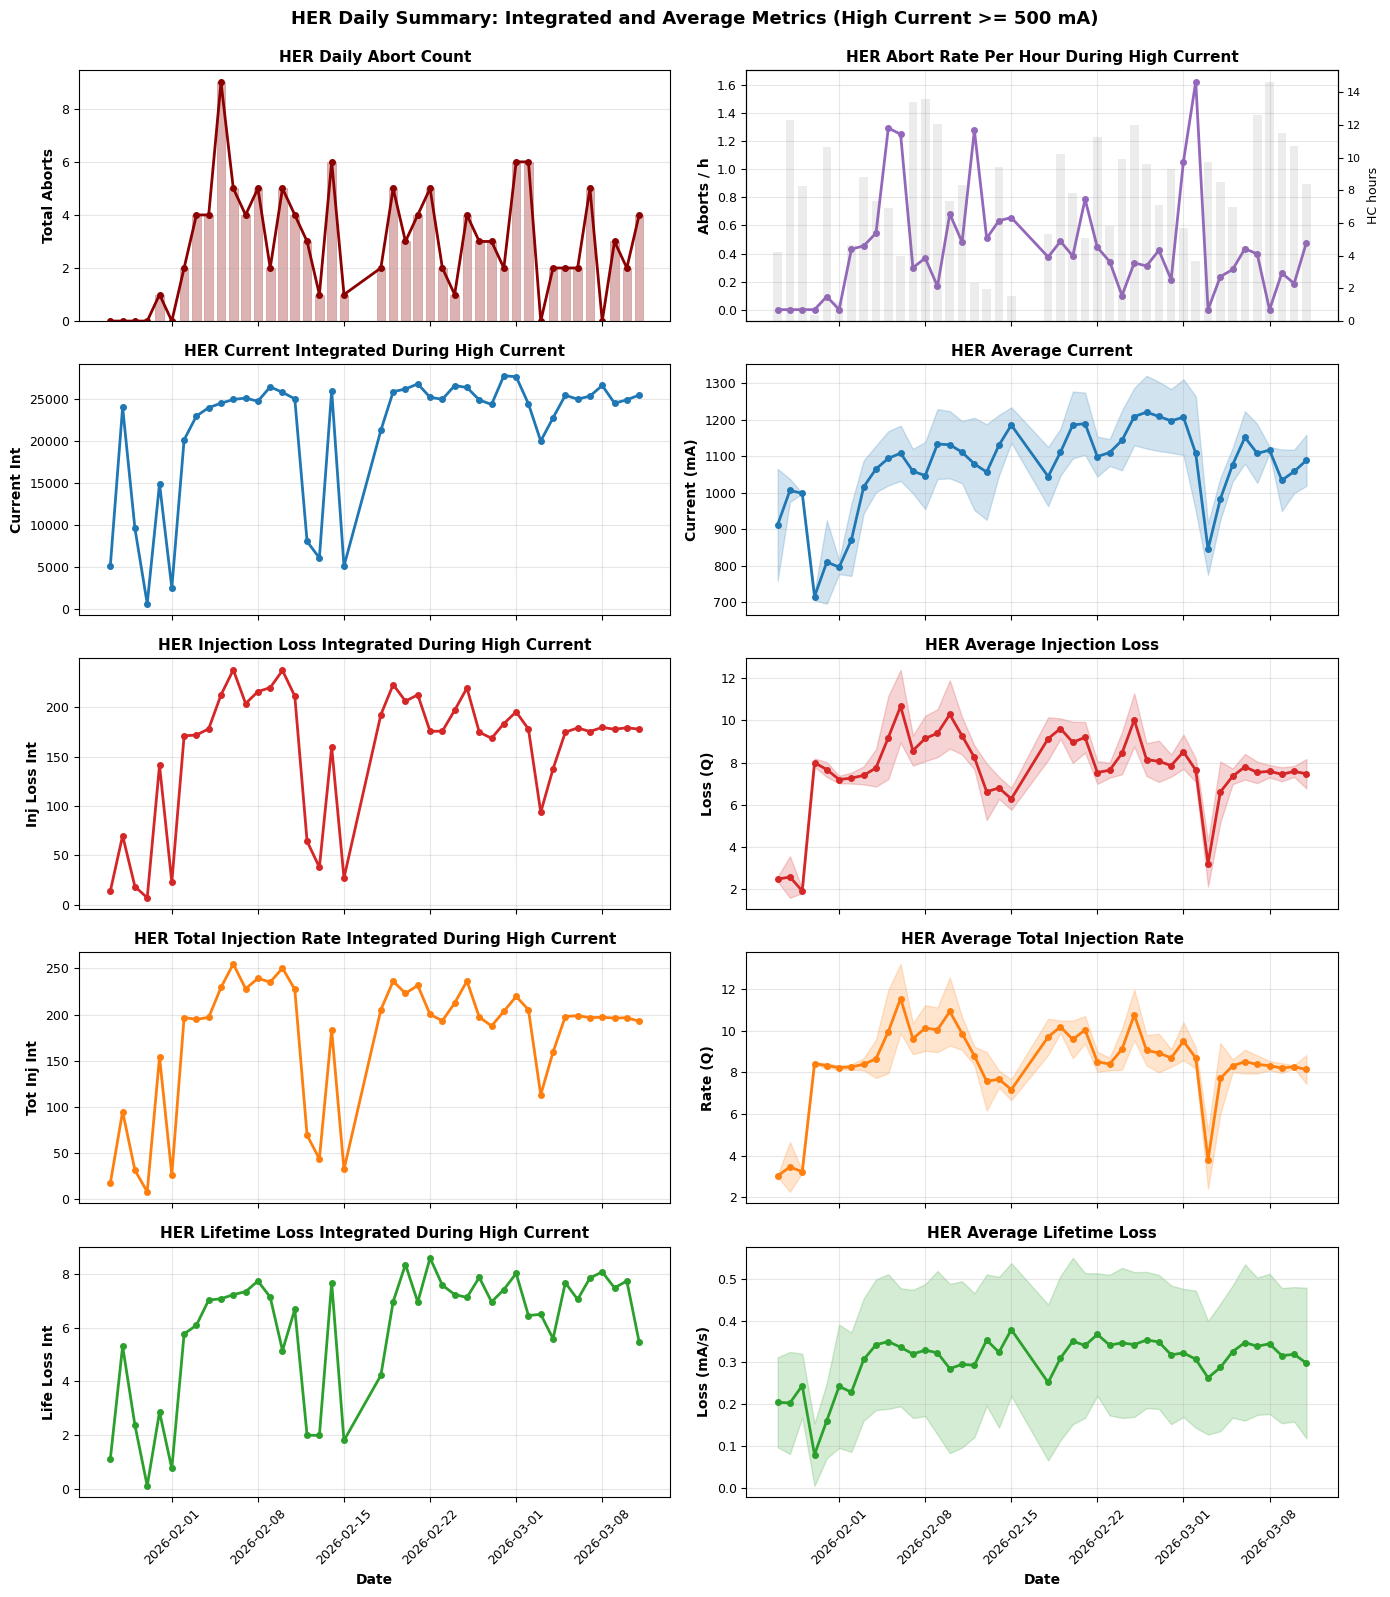


✓ HER visualization complete
  Total days analyzed: 42
  Date range: 20260127 to 20260311


In [107]:
# CELL: Visualization - 2-column daily summary layout for LER and HER

print("\n" + "=" * 80)
print("VISUALIZING DAILY SUMMARIES - LER AND HER")
print("=" * 80)

def plot_daily_summary_ring(summary_df, ring_name):
    if summary_df.empty:
        print(f"⚠ {ring_name}: no rows to visualize (current filters removed all days).")
        return

    plot_df = summary_df.copy()
    plot_df["date_dt"] = pd.to_datetime(plot_df["date"], format="%Y%m%d")
    plot_df = plot_df.sort_values("date_dt")

    fig, axes = plt.subplots(5, 2, figsize=(14, 16), sharex=True)

    # LEFT COLUMN: integrated metrics and abort count.
    ax = axes[0, 0]
    ax.bar(
        plot_df["date_dt"],
        plot_df["total_aborts"],
        alpha=0.3,
        color="darkred",
        edgecolor="darkred",
        linewidth=0.5,
        width=0.7,
    )
    ax.plot(
        plot_df["date_dt"],
        plot_df["total_aborts"],
        "o-",
        linewidth=2,
        markersize=4,
        color="darkred",
    )
    ax.set_ylabel("Total Aborts", fontsize=10, fontweight="bold")
    ax.set_title(f"{ring_name} Daily Abort Count", fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")

    ax = axes[1, 0]
    if "current_int_hc" in plot_df.columns and plot_df["current_int_hc"].notna().sum() > 0:
        ax.plot(plot_df["date_dt"], plot_df["current_int_hc"], "o-", linewidth=2, markersize=4, color="tab:blue")
    ax.set_ylabel("Current Int", fontsize=10, fontweight="bold")
    ax.set_title(f"{ring_name} Current Integrated During High Current", fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)

    ax = axes[2, 0]
    if "inj_loss_q_int_hc" in plot_df.columns and plot_df["inj_loss_q_int_hc"].notna().sum() > 0:
        ax.plot(plot_df["date_dt"], plot_df["inj_loss_q_int_hc"], "o-", linewidth=2, markersize=4, color="#d62728")
    ax.set_ylabel("Inj Loss Int", fontsize=10, fontweight="bold")
    ax.set_title(f"{ring_name} Injection Loss Integrated During High Current", fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)

    ax = axes[3, 0]
    if "total_inj_q_int_hc" in plot_df.columns and plot_df["total_inj_q_int_hc"].notna().sum() > 0:
        ax.plot(plot_df["date_dt"], plot_df["total_inj_q_int_hc"], "o-", linewidth=2, markersize=4, color="#ff7f0e")
    ax.set_ylabel("Tot Inj Int", fontsize=10, fontweight="bold")
    ax.set_title(f"{ring_name} Total Injection Rate Integrated During High Current", fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)

    ax = axes[4, 0]
    if "life_loss_int_hc" in plot_df.columns and plot_df["life_loss_int_hc"].notna().sum() > 0:
        ax.plot(plot_df["date_dt"], plot_df["life_loss_int_hc"], "o-", linewidth=2, markersize=4, color="#2ca02c")
    ax.set_ylabel("Life Loss Int", fontsize=10, fontweight="bold")
    ax.set_title(f"{ring_name} Lifetime Loss Integrated During High Current", fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)

    # RIGHT COLUMN: abort rate and average metrics.
    ax = axes[0, 1]
    has_rate = "abort_rate_per_hc_hour" in plot_df.columns and plot_df["abort_rate_per_hc_hour"].notna().sum() > 0
    if has_rate:
        ax.plot(
            plot_df["date_dt"],
            plot_df["abort_rate_per_hc_hour"],
            "o-",
            linewidth=2,
            markersize=4,
            color="tab:purple",
        )
    ax.set_ylabel("Aborts / h", fontsize=10, fontweight="bold")
    ax.set_title(f"{ring_name} Abort Rate Per Hour During High Current", fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)

    if "hc_exposure_hours" in plot_df.columns and plot_df["hc_exposure_hours"].notna().sum() > 0:
        ax_right = ax.twinx()
        ax_right.bar(
            plot_df["date_dt"],
            plot_df["hc_exposure_hours"],
            width=0.7,
            alpha=0.15,
            color="gray",
        )
        ax_right.set_ylabel("HC hours", fontsize=9)
        ax_right.tick_params(axis="y", labelsize=8)

    ax = axes[1, 1]
    if "current_avg" in plot_df.columns and plot_df["current_avg"].notna().sum() > 0:
        ax.plot(plot_df["date_dt"], plot_df["current_avg"], "o-", linewidth=2, markersize=4, color="tab:blue")
        if "current_std" in plot_df.columns:
            current_std = plot_df["current_std"].fillna(0)
            ax.fill_between(
                plot_df["date_dt"],
                plot_df["current_avg"] - current_std,
                plot_df["current_avg"] + current_std,
                alpha=0.2,
                color="tab:blue",
            )
    ax.set_ylabel("Current (mA)", fontsize=10, fontweight="bold")
    ax.set_title(f"{ring_name} Average Current", fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)

    ax = axes[2, 1]
    if "inj_loss_q_avg" in plot_df.columns and plot_df["inj_loss_q_avg"].notna().sum() > 0:
        ax.plot(plot_df["date_dt"], plot_df["inj_loss_q_avg"], "o-", linewidth=2, markersize=4, color="#d62728")
        ax.fill_between(
            plot_df["date_dt"],
            plot_df["inj_loss_q_avg"] - plot_df["inj_loss_q_std"],
            plot_df["inj_loss_q_avg"] + plot_df["inj_loss_q_std"],
            alpha=0.2,
            color="#d62728",
        )
    ax.set_ylabel("Loss (Q)", fontsize=10, fontweight="bold")
    ax.set_title(f"{ring_name} Average Injection Loss", fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)

    ax = axes[3, 1]
    if "total_inj_q_avg" in plot_df.columns and plot_df["total_inj_q_avg"].notna().sum() > 0:
        ax.plot(plot_df["date_dt"], plot_df["total_inj_q_avg"], "o-", linewidth=2, markersize=4, color="#ff7f0e")
        ax.fill_between(
            plot_df["date_dt"],
            plot_df["total_inj_q_avg"] - plot_df["total_inj_q_std"],
            plot_df["total_inj_q_avg"] + plot_df["total_inj_q_std"],
            alpha=0.2,
            color="#ff7f0e",
        )
    ax.set_ylabel("Rate (Q)", fontsize=10, fontweight="bold")
    ax.set_title(f"{ring_name} Average Total Injection Rate", fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)

    ax = axes[4, 1]
    if "life_loss_avg" in plot_df.columns and plot_df["life_loss_avg"].notna().sum() > 0:
        ax.plot(plot_df["date_dt"], plot_df["life_loss_avg"], "o-", linewidth=2, markersize=4, color="#2ca02c")
        ax.fill_between(
            plot_df["date_dt"],
            plot_df["life_loss_avg"] - plot_df["life_loss_std"],
            plot_df["life_loss_avg"] + plot_df["life_loss_std"],
            alpha=0.2,
            color="#2ca02c",
        )
    ax.set_ylabel("Loss (mA/s)", fontsize=10, fontweight="bold")
    ax.set_title(f"{ring_name} Average Lifetime Loss", fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3)

    axes[4, 0].set_xlabel("Date", fontsize=10, fontweight="bold")
    axes[4, 1].set_xlabel("Date", fontsize=10, fontweight="bold")

    for row_axes in axes:
        for axis in row_axes:
            axis.tick_params(axis="x", rotation=45, labelsize=9)
            axis.tick_params(axis="y", labelsize=9)

    plt.suptitle(
        f"{ring_name} Daily Summary: Integrated and Average Metrics (High Current >= {HIGH_CURRENT_THRESHOLD} mA)",
        fontsize=13,
        fontweight="bold",
        y=0.995,
    )
    plt.tight_layout()
    plt.show()

    print(f"\n✓ {ring_name} visualization complete")
    print(f"  Total days analyzed: {len(plot_df)}")
    print(f"  Date range: {plot_df['date'].min()} to {plot_df['date'].max()}")

if "daily_summary_df_ler" not in globals() or "daily_summary_df_her" not in globals():
    raise ValueError("Run Cell 8 first to create daily_summary_df_ler and daily_summary_df_her.")

plot_daily_summary_ring(daily_summary_df_ler, "LER")
plot_daily_summary_ring(daily_summary_df_her, "HER")